<a href="https://www.kaggle.com/code/kotikalayashwant/rnn-poa?scriptVersionId=315318165" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Reproducing: Enhancing Recurrent Neural Networks with Positional Attention for Question Answering

**Paper**: Chen et al., SIGIR 2017

This notebook implements the **RNN-POA** (Positional-Attention) model for answer selection.

**Key contributions reproduced**:
1. Shared Bidirectional LSTM encoder for questions and answers
2. Gaussian-kernel position-aware influence propagation
3. Positional attention mechanism over answer hidden states
4. Manhattan distance similarity with ℓ₁ norm

**Evaluated on**: WikiQA **and** TREC-QA (clean) datasets with MAP and MRR metrics.

## 1. Environment Setup

In [1]:
# Install required packages (for Colab/Kaggle)
# !pip install -q datasets nltk matplotlib tqdm

import os, sys, math, re, random, warnings, zipfile, urllib.request
from collections import Counter, defaultdict

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import nltk
from datasets import load_dataset

# Download NLTK tokenizer data (may fail in some environments)
try:
    nltk.download('punkt', quiet=True)
    nltk.download('punkt_tab', quiet=True)
except Exception:
    pass
warnings.filterwarnings('ignore')

# ── GPU configuration ──
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if device.type == 'cuda':
    print(f'  GPU: {torch.cuda.get_device_name(0)}')

# ── Reproducibility ──
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

print('Environment ready.')

Using device: cuda
  GPU: Tesla T4
Environment ready.


## 2. GloVe Embeddings (100d)

We download the pre-trained GloVe 6B 100-dimensional word vectors.
These provide a fixed, general-purpose word representation layer.

In [2]:
GLOVE_DIR = 'glove_data'
GLOVE_FILE = os.path.join(GLOVE_DIR, 'glove.6B.100d.txt')
GLOVE_ZIP  = os.path.join(GLOVE_DIR, 'glove.6B.zip')
GLOVE_URL  = 'https://nlp.stanford.edu/data/glove.6B.zip'
EMBED_DIM  = 100

def download_glove():
    """Download and extract GloVe embeddings if not present."""
    os.makedirs(GLOVE_DIR, exist_ok=True)
    if not os.path.exists(GLOVE_FILE):
        if not os.path.exists(GLOVE_ZIP):
            print('Downloading GloVe (this may take a few minutes)...')
            urllib.request.urlretrieve(GLOVE_URL, GLOVE_ZIP)
        print('Extracting...')
        with zipfile.ZipFile(GLOVE_ZIP, 'r') as z:
            z.extract('glove.6B.100d.txt', GLOVE_DIR)
        print('Done.')
    else:
        print('GloVe file already exists.')

def load_glove(path, embed_dim=100):
    """Parse GloVe text file into {word: vector} dict."""
    embeddings = {}
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            parts = line.rstrip().split(' ')
            word = parts[0]
            vec  = np.array(parts[1:], dtype=np.float32)
            if len(vec) == embed_dim:
                embeddings[word] = vec
    print(f'Loaded {len(embeddings):,} GloVe vectors.')
    return embeddings

download_glove()
glove_vectors = load_glove(GLOVE_FILE, EMBED_DIM)

Extracting...
Done.
Loaded 400,000 GloVe vectors.


## 3. Dataset Loading & Preprocessing

+### Datasets: WikiQA and TREC-QA (Clean)
+
+We use **both** benchmark datasets from the original paper:
+
+1. **WikiQA** (Yang et al., 2015) – open-domain questions from Bing query logs
+   paired with candidate answer sentences from Wikipedia.
+2. **TREC-QA** (Wang et al., 2007) – factoid questions from TREC 8-13 QA tracks.
+   We use the **clean** version (questions with at least one positive and one
+   negative candidate), as used in the paper.
+
+Both datasets have binary labels (relevant / not relevant) and are evaluated
+with MAP and MRR metrics.

In [3]:
from datasets import load_dataset, load_from_disk
import os


CACHE_DIR = "./hf_datasets"

os.makedirs(CACHE_DIR, exist_ok=True)


wikiqa_path = os.path.join(CACHE_DIR, "wiki_qa")

if os.path.exists(wikiqa_path):
    print("Loading WikiQA from local disk...")
    wiki_qa = load_from_disk(wikiqa_path)
else:
    print("Downloading WikiQA from HuggingFace...")
    wiki_qa = load_dataset("wiki_qa")
    wiki_qa.save_to_disk(wikiqa_path)
    print("Saved WikiQA locally.")

print("Splits:", list(wiki_qa.keys()))
for split in wiki_qa:
    pos = sum(1 for x in wiki_qa[split] if x["label"] == 1)
    print(f"  {split}: {len(wiki_qa[split])} pairs, {pos} positive")



print("\n" + "="*60)
print("TREC-QA")
print("="*60)

trecqa_path = os.path.join(CACHE_DIR, "trec_qa")

if os.path.exists(trecqa_path):
    print("Loading TREC-QA from local disk...")
    trec_qa_raw = load_from_disk(trecqa_path)
else:
    print("Downloading TREC-QA from HuggingFace...")
    trec_qa_raw = load_dataset("lucadiliello/trecqa")
    trec_qa_raw.save_to_disk(trecqa_path)
    print("Saved TREC-QA locally.")

print("Available splits:", list(trec_qa_raw.keys()))
for split in trec_qa_raw:
    pos = sum(1 for x in trec_qa_raw[split] if x["label"] == 1)
    print(f"  {split}: {len(trec_qa_raw[split])} pairs, {pos} positive")

README.md: 0.00B [00:00, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/594k [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/264k [00:00<?, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/2.00M [00:00<?, ?B/s]

Generating test split:   0%|          | 0/6165 [00:00<?, ? examples/s]

...

Saving the dataset (0/1 shards):   0%|          | 0/1364 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1343 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1442 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/53417 [00:00<?, ? examples/s]

Saved TREC-QA locally.
Available splits: ['train', 'test', 'dev', 'dev_clean', 'test_clean', 'train_all']
  train: 5919 pairs, 475 positive
  test: 1517 pairs, 284 positive
  dev: 1364 pairs, 264 positive
  dev_clean: 1343 pairs, 243 positive
  test_clean: 1442 pairs, 248 positive
  train_all: 53417 pairs, 6410 positive


In [4]:
# ── Tokenisation & vocabulary building ──
import re

def tokenize(text):
    """
    Lowercase and tokenize text.
    Tries NLTK word_tokenize first; falls back to regex-based
    splitting if NLTK punkt data is unavailable.
    """
    text = text.lower()
    try:
        from nltk.tokenize import word_tokenize
        return word_tokenize(text)
    except LookupError:
        # Fallback: split on non-alphanumeric, keeping tokens
        return [t for t in re.findall(r"\w+|[^\w\s]", text) if t.strip()]

# Build vocabulary from BOTH training sets
word_counts = Counter()

# WikiQA train vocabulary
for ex in wiki_qa['train']:
    word_counts.update(tokenize(ex['question']))
    word_counts.update(tokenize(ex['answer']))

# TREC-QA train vocabulary
for ex in trec_qa_raw['train']:
    word_counts.update(tokenize(ex['question']))
    word_counts.update(tokenize(ex['answer']))

# Special tokens
PAD_TOKEN = '<PAD>'
UNK_TOKEN = '<UNK>'
word2idx = {PAD_TOKEN: 0, UNK_TOKEN: 1}
for w, _ in word_counts.most_common():
    word2idx[w] = len(word2idx)
idx2word = {v: k for k, v in word2idx.items()}
VOCAB_SIZE = len(word2idx)
print(f'Vocabulary size: {VOCAB_SIZE:,}')

Vocabulary size: 40,428


In [5]:
# ── Build embedding matrix aligned to our vocabulary ──
embedding_matrix = np.random.uniform(-0.25, 0.25, (VOCAB_SIZE, EMBED_DIM)).astype(np.float32)
embedding_matrix[0] = np.zeros(EMBED_DIM)  # PAD = zero vector

found = 0
for word, idx in word2idx.items():
    if word in glove_vectors:
        embedding_matrix[idx] = glove_vectors[word]
        found += 1
print(f'GloVe coverage: {found}/{VOCAB_SIZE} ({100*found/VOCAB_SIZE:.1f}%)')

# Free memory
del glove_vectors

GloVe coverage: 35294/40428 (87.3%)


In [6]:
# ── Dataset class ──
MAX_Q_LEN = 40   # max question length (tokens)
MAX_A_LEN = 100  # max answer length (tokens)

def encode_and_pad(tokens, max_len):
    """Convert tokens to indices, truncate/pad to max_len."""
    ids = [word2idx.get(t, word2idx[UNK_TOKEN]) for t in tokens]
    ids = ids[:max_len]
    length = len(ids)
    ids += [word2idx[PAD_TOKEN]] * (max_len - length)
    return ids, length

def find_question_positions(q_tokens, a_tokens):
    """
    Find positions in the answer where question words appear.
    Returns a list of answer-position indices.
    This is the set Q_a from the paper: positions in the answer
    where a question word is found.
    """
    q_set = set(q_tokens)
    return [i for i, tok in enumerate(a_tokens) if tok in q_set]

class QADataset(Dataset):
    def __init__(self, hf_split, qid_field='question_id'):
        self.samples = []
        for idx, ex in enumerate(hf_split):
            q_tok = tokenize(ex['question'])
            a_tok = tokenize(ex['answer'])
            q_ids, q_len = encode_and_pad(q_tok, MAX_Q_LEN)
            a_ids, a_len = encode_and_pad(a_tok, MAX_A_LEN)
            # positions of question words in the (truncated) answer
            q_positions = find_question_positions(q_tok, a_tok[:MAX_A_LEN])
            # Get question ID — use field if available, else hash the question text
            if qid_field in ex:
                qid = ex[qid_field]
            else:
                qid = hash(ex['question']) % (10**8)
                
            label = ex.get('label', 0)

            self.samples.append({
                'q_ids':  torch.tensor(q_ids,  dtype=torch.long),
                'a_ids':  torch.tensor(a_ids,  dtype=torch.long),
                'q_len':  q_len,
                'a_len':  a_len,
                'q_pos':  q_positions,
                'label':  torch.tensor(label,  dtype=torch.float32),
                'qid':    qid,
            })

    def __len__(self): return len(self.samples)
    def __getitem__(self, idx): return self.samples[idx]


def collate_fn(batch):
    """Custom collate: stack tensors, keep q_pos as list-of-lists."""
    return {
        'q_ids':  torch.stack([b['q_ids'] for b in batch]),
        'a_ids':  torch.stack([b['a_ids'] for b in batch]),
        'q_len':  torch.tensor([b['q_len'] for b in batch]),
        'a_len':  torch.tensor([b['a_len'] for b in batch]),
        'q_pos':  [b['q_pos'] for b in batch],
        'label':  torch.stack([b['label'] for b in batch]),
        'qid':    [b['qid'] for b in batch],
    }

# Build datasets and loaders
BATCH_SIZE = 64
# WikiQA loaders
wiki_train_ds = QADataset(wiki_qa['train'], qid_field='question_id')
wiki_dev_ds   = QADataset(wiki_qa['validation'], qid_field='question_id')
wiki_test_ds  = QADataset(wiki_qa['test'], qid_field='question_id')

wiki_train_loader = DataLoader(wiki_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
wiki_dev_loader   = DataLoader(wiki_dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
wiki_test_loader  = DataLoader(wiki_test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'Train: {len(wiki_train_ds)}, Dev: {len(wiki_dev_ds)}, Test: {len(wiki_test_ds)}')

Train: 20360, Dev: 2733, Test: 6165


In [7]:
trec_train_ds = QADataset(trec_qa_raw['train'], qid_field='question_id')

available_splits = list(trec_qa_raw.keys())
trec_dev_split  = 'dev_clean'  if 'dev_clean'  in available_splits else 'validation'
trec_test_split = 'test_clean' if 'test_clean' in available_splits else 'test'

trec_dev_ds  = QADataset(trec_qa_raw[trec_dev_split],  qid_field='question_id')
trec_test_ds = QADataset(trec_qa_raw[trec_test_split], qid_field='question_id')

trec_train_loader = DataLoader(trec_train_ds, batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collate_fn)
trec_dev_loader   = DataLoader(trec_dev_ds,   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
trec_test_loader  = DataLoader(trec_test_ds,  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

print(f'TREC-QA — Train: {len(trec_train_ds)}, Dev ({trec_dev_split}): {len(trec_dev_ds)}, Test ({trec_test_split}): {len(trec_test_ds)}')

TREC-QA — Train: 5919, Dev (dev_clean): 1343, Test (test_clean): 1442


## 4. Model Architecture

The RNN-POA model has four key components:

1. **Shared BLSTM Encoder** – encodes both question and answer with tied weights
2. **Gaussian Kernel** – propagates question-word influence to neighbouring answer positions
3. **Positional Attention** – combines classical attention with position-aware influence
4. **Manhattan Similarity** – measures question-answer relevance via $\exp(-\|h_q - h_a\|_1)$

In [8]:
class SharedBLSTM(nn.Module):
    """
    Shared Bidirectional LSTM encoder.
    The same BLSTM weights encode both question and answer sentences,
    ensuring the representations live in the same space.

    Input:  (batch, seq_len)  token indices
    Output: (batch, seq_len, 2*hidden_dim)  hidden states
            (batch, 2*hidden_dim)  final pooled representation
    """
    def __init__(self, embed_matrix, hidden_dim=50, dropout=0.2):
        super().__init__()
        vocab_size, embed_dim = embed_matrix.shape
        self.hidden_dim = hidden_dim
        self.output_dim = hidden_dim * 2
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.embedding.weight = nn.Parameter(
            torch.tensor(embed_matrix, dtype=torch.float32), requires_grad=False
        )  # Freeze pre-trained GloVe

        self.lstm = nn.LSTM(
            input_size=embed_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=True,
            dropout=dropout,
            num_layers=1,
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, token_ids, lengths):
        """
        Args:
            token_ids: (batch, max_len) padded token indices
            lengths:   (batch,) actual lengths
        Returns:
            hidden_states: (batch, max_len, 2*hidden_dim)
            pooled:        (batch, 2*hidden_dim) mean-pooled over valid positions
        """
        embeds = self.dropout(self.embedding(token_ids))  # (B, L, E)

        # Pack for efficient LSTM processing
        lengths_cpu = lengths.cpu().clamp(min=1)
        packed = nn.utils.rnn.pack_padded_sequence(
            embeds, lengths_cpu, batch_first=True, enforce_sorted=False
        )
        packed_out, _ = self.lstm(packed)
        hidden_states, _ = nn.utils.rnn.pad_packed_sequence(
            packed_out, batch_first=True, total_length=token_ids.size(1)
        )  # (B, L, 2H)

        # Mean-pool over valid (non-padded) positions
        mask = (token_ids != 0).unsqueeze(-1).float()  # (B, L, 1)
        pooled = (hidden_states * mask).sum(dim=1) / mask.sum(dim=1).clamp(min=1)
        return hidden_states, pooled

### 4.1 Gaussian Kernel for Position-Aware Influence

The key insight of the paper: if question word $q_j$ appears at position $j$ in the
answer, neighbouring answer words are likely relevant too. The influence decays with
distance according to a Gaussian kernel:

$$K(p, q_j) = \exp\!\left(-\frac{(p - q_j)^2}{2\sigma'^{\,2}}\right)$$

where $\sigma' = 0.1$ (set empirically) and $p$ ranges over all answer positions.

The cumulative influence at answer position $p$ is:

$$\hat{d}_p = \sum_{q_j \in Q_a} K(p, q_j)$$

where $Q_a$ is the set of answer positions where a question word appears.
Only positions within the propagation scope $\sigma$ contribute.

In [9]:
def compute_position_influence(a_len, q_positions, max_a_len, sigma_scope=25, sigma_prime=0.1):
    """
    Compute the position-aware influence vector d_hat for one sample.

    Math:
      d_hat[p] = sum_{q_j in Q_a} exp(-(p - q_j)^2 / (2 * sigma'^2))
      Only positions within |p - q_j| <= sigma_scope contribute.

    Args:
        a_len:        actual answer length
        q_positions:  list of answer-indices where question words appear
        max_a_len:    padded answer length
        sigma_scope:  propagation scope (paper: 15-35, default 25)
        sigma_prime:  Gaussian std dev (paper: 0.1)

    Returns:
        d_hat: (max_a_len,) tensor of influence values
    """
    d_hat = torch.zeros(max_a_len)
    if len(q_positions) == 0:
        return d_hat

    for p in range(a_len):
        influence = 0.0
        for qj in q_positions:
            if abs(p - qj) <= sigma_scope:
                influence += math.exp(-((p - qj) ** 2) / (2 * sigma_prime ** 2))
        d_hat[p] = influence

    # Normalise to [0, 1] to prevent scale issues
    if d_hat.max() > 0:
        d_hat = d_hat / d_hat.max()
    return d_hat


def batch_position_influence(a_lens, q_positions_list, max_a_len, sigma_scope=25, sigma_prime=0.1):
    """
    Compute position influence for a whole batch.
    Returns: (batch, max_a_len) tensor.
    """
    batch_d = []
    for i in range(len(a_lens)):
        d = compute_position_influence(
            a_lens[i].item() if torch.is_tensor(a_lens[i]) else a_lens[i],
            q_positions_list[i], max_a_len, sigma_scope, sigma_prime
        )
        batch_d.append(d)
    return torch.stack(batch_d)  # (B, L_a)

### 4.2 Positional Attention Mechanism

Classical attention computes:
$$\alpha_p = \frac{\exp(s(h^a_p, h^q))}{\sum_k \exp(s(h^a_k, h^q))}$$

The paper augments this with the positional influence $\hat{d}_p$:
$$\tilde{\alpha}_p = \frac{\exp(s(h^a_p, h^q)) \cdot (1 + \hat{d}_p)}{\sum_k \exp(s(h^a_k, h^q)) \cdot (1 + \hat{d}_k)}$$

The attended answer representation is $\tilde{h}^a = \sum_p \tilde{\alpha}_p \, h^a_p$.

In [10]:
class PositionalAttention(nn.Module):
    """
    Positional Attention (RNN-POA) Layer.

    Combines classical bilinear attention with position-aware influence
    to weight the answer hidden states. The position-aware influence
    vector d_hat up-weights answer positions near question-word occurrences.
    """
    def __init__(self, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        # Bilinear scoring: s(h_a, h_q) = h_a^T W h_q
        self.W = nn.Linear(hidden_dim, hidden_dim, bias=False)

    def forward(self, a_hidden, q_pooled, a_mask, d_hat):
        """
        Args:
            a_hidden: (B, L_a, 2H)  answer hidden states
            q_pooled: (B, 2H)       question representation
            a_mask:   (B, L_a)      1 for valid positions, 0 for padding
            d_hat:    (B, L_a)      position-aware influence vector

        Returns:
            attended: (B, 2H)  position-aware attended answer representation
        """
        if a_hidden.size(-1) != self.hidden_dim:
            raise RuntimeError(
                f"PositionalAttention expected hidden size {self.hidden_dim}, "
                f"but received {a_hidden.size(-1)}. Check encoder/attention dimension wiring."
            )
        if q_pooled.size(-1) != self.hidden_dim:
            raise RuntimeError(
                f"PositionalAttention expected pooled question size {self.hidden_dim}, "
                f"but received {q_pooled.size(-1)}. Check encoder/attention dimension wiring."
            )
        # Bilinear attention scores: s(h_a_p, h_q) = h_a_p^T W h_q
        Wq = self.W(q_pooled)          # (B, 2H)
        scores = torch.bmm(
            a_hidden, Wq.unsqueeze(2)
        ).squeeze(2)                    # (B, L_a)

        # Mask padding positions with large negative value
        scores = scores.masked_fill(a_mask == 0, -1e9)

        # Classical attention weights
        exp_scores = torch.exp(scores - scores.max(dim=1, keepdim=True).values)  # numerical stability
        exp_scores = exp_scores * a_mask  # zero out padding

        # ── Positional modulation ──
        # Multiply by (1 + d_hat) so positions near question words get boosted
        modulated = exp_scores * (1.0 + d_hat)

        # Normalise to get positional attention weights
        alpha = modulated / modulated.sum(dim=1, keepdim=True).clamp(min=1e-9)  # (B, L_a)

        # Weighted sum of answer hidden states
        attended = torch.bmm(alpha.unsqueeze(1), a_hidden).squeeze(1)  # (B, 2H)
        return attended

### 4.3 Full RNN-POA Model

Similarity is computed via Manhattan distance with $\ell_1$ norm:
$$\text{sim}(q, a) = \exp\!\left(-\|h^q - \tilde{h}^a\|_1\right)$$

This similarity score ∈ (0, 1] is used as the probability of relevance.

In [11]:
class RNNPOA(nn.Module):
    """
    RNN with Positional Attention for Answer Selection.

    Architecture:
      1. Shared BLSTM encodes question and answer
      2. Position-aware influence propagation (Gaussian kernel)
      3. Positional attention over answer hidden states
      4. Manhattan distance similarity
    """
    def __init__(self, embed_matrix, hidden_dim=50, sigma_scope=25, sigma_prime=0.1, dropout=0.2):
        super().__init__()
        self.hidden_dim   = hidden_dim
        self.sigma_scope  = sigma_scope   # Propagation scope (paper: 15-35)
        self.sigma_prime  = sigma_prime   # Gaussian std dev (paper: 0.1)

        self.encoder      = SharedBLSTM(embed_matrix, hidden_dim, dropout)
        self.pos_attn     = PositionalAttention(self.encoder.output_dim)

    def forward(self, q_ids, a_ids, q_len, a_len, q_pos):
        """
        Args:
            q_ids:  (B, L_q) question token ids
            a_ids:  (B, L_a) answer token ids
            q_len:  (B,) question lengths
            a_len:  (B,) answer lengths
            q_pos:  list of lists – positions in answer where question words appear

        Returns:
            sim: (B,) similarity scores in (0, 1]
        """
        # ── Encode ──
        _, q_pooled         = self.encoder(q_ids, q_len)       # (B, 2H)
        a_hidden, _         = self.encoder(a_ids, a_len)       # (B, L_a, 2H)

        # ── Position-aware influence (Gaussian kernel) ──
        d_hat = batch_position_influence(
            a_len, q_pos, a_ids.size(1),
            self.sigma_scope, self.sigma_prime
        ).to(a_hidden.device)  # (B, L_a)

        # ── Positional attention ──
        a_mask = (a_ids != 0).float()  # (B, L_a)
        a_attended = self.pos_attn(a_hidden, q_pooled, a_mask, d_hat)  # (B, 2H)

        # ── Manhattan distance similarity ──
        # sim(q, a) = exp(-||h_q - h_a||_1)
        sim = torch.exp(-torch.sum(torch.abs(q_pooled - a_attended), dim=1))  # (B,)
        return sim


# ── Baseline: Attention-BLSTM WITHOUT positional info ──
class AttentionBLSTM(nn.Module):
    """
    Baseline: classical attention-based BLSTM (no positional influence).
    Used for comparison to show the benefit of positional attention.
    """
    def __init__(self, embed_matrix, hidden_dim=50, dropout=0.2):
        super().__init__()
        self.encoder = SharedBLSTM(embed_matrix, hidden_dim, dropout)
        self.W = nn.Linear(self.encoder.output_dim, self.encoder.output_dim, bias=False)

    def forward(self, q_ids, a_ids, q_len, a_len, q_pos):
        _, q_pooled   = self.encoder(q_ids, q_len)
        a_hidden, _   = self.encoder(a_ids, a_len)

        Wq = self.W(q_pooled)
        scores = torch.bmm(a_hidden, Wq.unsqueeze(2)).squeeze(2)
        a_mask = (a_ids != 0).float()
        scores = scores.masked_fill(a_mask == 0, -1e9)
        alpha  = F.softmax(scores, dim=1)
        a_attended = torch.bmm(alpha.unsqueeze(1), a_hidden).squeeze(1)

        sim = torch.exp(-torch.sum(torch.abs(q_pooled - a_attended), dim=1))
        return sim

### 4.4 Baseline: RNN-AVG (Average Pooling)

The simplest baseline for sentence representation is **average pooling** over the
BLSTM hidden states.  Given the hidden state sequence $\{h_1, h_2, \dots, h_L\}$
produced by the shared BLSTM encoder, the sentence representation is simply:

$$r = \frac{1}{L} \sum_{p=1}^{L} h_p$$

This is applied independently to both the question and the answer.

**Why use this as a baseline?**
- It provides a *lower bound* on performance: there is no learned weighting of
  positions, no attention, and no positional information.
- Comparing RNN-AVG → RNN-ATT shows the benefit of **attention**.
- Comparing RNN-ATT → RNN-POA shows the additional benefit of **positional attention**.

**How it differs from the other models:**

| Model   | Question repr. | Answer repr.          | Learned weighting? | Position-aware? |
|---------|----------------|-----------------------|--------------------|-----------------|
| RNN-AVG | avg-pool       | avg-pool              | No                 | No              |
| RNN-ATT | avg-pool       | attention-weighted     | Yes                | No              |
| RNN-POA | avg-pool       | positional-attention   | Yes                | Yes             |

Note: the `SharedBLSTM` encoder already computes a mean-pooled representation (`pooled`)
as one of its outputs, so RNN-AVG simply uses that directly for both question and answer.

In [12]:
# ── Baseline: Average-Pooling BLSTM (no attention at all) ──
class AvgPoolBLSTM(nn.Module):
    """
    Baseline: RNN-AVG — average pooling over BLSTM hidden states.

    Both question and answer representations are computed as:
        r = (1/L) * sum(h_i)  for i = 1..L  (valid, non-padded positions)

    This is the simplest baseline: no attention mechanism, no positional
    information.  SharedBLSTM already computes this mean-pooled output,
    so we just use it directly.

    Similarity is computed via Manhattan distance:
        sim(q, a) = exp(-||r_q - r_a||_1)
    """
    def __init__(self, embed_matrix, hidden_dim=50, dropout=0.2):
        super().__init__()
        self.encoder = SharedBLSTM(embed_matrix, hidden_dim, dropout)

    def forward(self, q_ids, a_ids, q_len, a_len, q_pos):
        """
        Args:
            q_ids:  (B, L_q) question token ids
            a_ids:  (B, L_a) answer token ids
            q_len:  (B,) question lengths
            a_len:  (B,) answer lengths
            q_pos:  list of lists – UNUSED (kept for interface compatibility)

        Returns:
            sim: (B,) similarity scores in (0, 1]
        """
        # ── Encode question and answer ──
        _, q_pooled = self.encoder(q_ids, q_len)   # (B, 2H)  mean-pooled
        _, a_pooled = self.encoder(a_ids, a_len)   # (B, 2H)  mean-pooled

        # ── Manhattan distance similarity ──
        # sim(q, a) = exp(-||r_q - r_a||_1)
        sim = torch.exp(-torch.sum(torch.abs(q_pooled - a_pooled), dim=1))  # (B,)
        return sim

## 5. Evaluation Metrics: MAP & MRR

**Mean Average Precision (MAP)**: For each question, compute average precision
over its ranked candidate answers, then average across all questions.

**Mean Reciprocal Rank (MRR)**: For each question, find the rank of the first
correct answer, take its reciprocal, then average across all questions.

In [13]:
def compute_metrics(qid_list, scores, labels):
    """
    Compute MAP and MRR for answer selection.

    Groups predictions by question ID, ranks answers by predicted score,
    and computes MAP and MRR.

    Args:
        qid_list: list of question IDs (one per sample)
        scores:   np.array of predicted similarity scores
        labels:   np.array of ground-truth binary labels

    Returns:
        (MAP, MRR) tuple
    """
    # Group by question ID
    groups = defaultdict(list)
    for qid, score, label in zip(qid_list, scores, labels):
        groups[qid].append((score, label))

    avg_precisions = []
    reciprocal_ranks = []

    for qid, pairs in groups.items():
        # Sort by score descending
        pairs.sort(key=lambda x: x[0], reverse=True)
        sorted_labels = [p[1] for p in pairs]

        # Skip questions with no positive answer
        if sum(sorted_labels) == 0:
            continue

        # Average Precision
        num_correct = 0
        precision_sum = 0.0
        for rank, lbl in enumerate(sorted_labels, 1):
            if lbl == 1:
                num_correct += 1
                precision_sum += num_correct / rank
        ap = precision_sum / num_correct
        avg_precisions.append(ap)

        # Reciprocal Rank
        for rank, lbl in enumerate(sorted_labels, 1):
            if lbl == 1:
                reciprocal_ranks.append(1.0 / rank)
                break

    MAP = np.mean(avg_precisions) if avg_precisions else 0.0
    MRR = np.mean(reciprocal_ranks) if reciprocal_ranks else 0.0
    return MAP, MRR


@torch.no_grad()
def evaluate(model, loader):
    """Run model on a data loader and return loss, MAP, MRR."""
    model.eval()
    all_scores, all_labels, all_qids = [], [], []
    total_loss = 0.0
    n_batches = 0

    for batch in loader:
        q_ids = batch['q_ids'].to(device)
        a_ids = batch['a_ids'].to(device)
        q_len = batch['q_len'].to(device)
        a_len = batch['a_len'].to(device)
        labels = batch['label'].to(device)

        sim = model(q_ids, a_ids, q_len, a_len, batch['q_pos'])
        sim = sim.clamp(1e-7, 1 - 1e-7)  # numerical safety
        loss = F.binary_cross_entropy(sim, labels)
        total_loss += loss.item()
        n_batches += 1

        all_scores.extend(sim.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_qids.extend(batch['qid'])

    avg_loss = total_loss / max(n_batches, 1)
    MAP, MRR = compute_metrics(all_qids, np.array(all_scores), np.array(all_labels))
    return avg_loss, MAP, MRR

## 6. Training Loop

- **Loss**: Binary cross-entropy (relevant=1, irrelevant=0)
- **Optimizer**: Adadelta (as per the paper)
- **Early stopping**: based on dev MAP

In [14]:
def train_model(model, train_loader, dev_loader,
                n_epochs=30, patience=5, lr=1.0,
                save_name='best_model.pt'):

    optimizer = torch.optim.Adadelta(model.parameters(), lr=lr)

    best_dev_map = 0.0
    patience_counter = 0

    history = {
        'train_loss': [],
        'dev_loss': [],
        'dev_map': [],
        'dev_mrr': []
    }

    for epoch in range(1, n_epochs + 1):

        model.train()
        epoch_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f'Epoch {epoch}/{n_epochs}', leave=False)

        for batch in pbar:
            q_ids = batch['q_ids'].to(device)
            a_ids = batch['a_ids'].to(device)
            q_len = batch['q_len'].to(device)
            a_len = batch['a_len'].to(device)
            labels = batch['label'].to(device)

            optimizer.zero_grad()

            sim = model(q_ids, a_ids, q_len, a_len, batch['q_pos'])
            sim = sim.clamp(1e-7, 1 - 1e-7)

            loss = F.binary_cross_entropy(sim, labels)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)

            optimizer.step()

            epoch_loss += loss.item()
            n_batches += 1

            pbar.set_postfix(loss=f'{loss.item():.4f}')

        avg_train_loss = epoch_loss / max(n_batches, 1)

        dev_loss, dev_map, dev_mrr = evaluate(model, dev_loader)

        history['train_loss'].append(avg_train_loss)
        history['dev_loss'].append(dev_loss)
        history['dev_map'].append(dev_map)
        history['dev_mrr'].append(dev_mrr)

        print(f"Epoch {epoch:2d} | "
              f"Train Loss: {avg_train_loss:.4f} | "
              f"Dev Loss: {dev_loss:.4f} | "
              f"Dev MAP: {dev_map:.4f} | "
              f"Dev MRR: {dev_mrr:.4f}")

        # Save best model
        if dev_map > best_dev_map:
            best_dev_map = dev_map
            patience_counter = 0

            torch.save(model.state_dict(), save_name)
            print(f"Saved best model -> {save_name}")

        else:
            patience_counter += 1

            if patience_counter >= patience:
                print(f"Early stopping at epoch {epoch}")
                break

    # Load best weights back
    model.load_state_dict(torch.load(save_name, map_location=device))

    return history

In [15]:
HIDDEN_DIM  = 50
SIGMA_SCOPE = 25
SIGMA_PRIME = 0.1
N_EPOCHS    = 30
PATIENCE    = 5
LR          = 1.0

## 6.1 Hyperparameter Tuning: Propagation Scope (σ)

The propagation scope parameter σ (`sigma_scope`) controls how far the Gaussian-kernel
influence of a matched question word propagates to neighbouring answer positions.

**From the paper (Section 4.2):**
> "We vary σ from 5 to 55 with a step of 10 and select the value that gives
> the best MAP on the development set."

We evaluate σ ∈ {5, 15, 25, 35, 45, 55}, train a fresh RNN-POA model for each
value on the training set, and evaluate on the dev set.  The best σ is chosen
based on the **highest dev MAP**.

In [16]:
# ═══════════════════════════════════════════════════════════════
#  Hyperparameter Tuning: Propagation Scope (σ)
# ═══════════════════════════════════════════════════════════════

SIGMA_VALUES = [5, 15, 25, 35, 45, 55]

# We'll tune on WikiQA (you can repeat for TREC-QA similarly)
sigma_results = []     # list of dicts: {sigma, map, mrr}

for sigma_val in SIGMA_VALUES:
    print(f'\n{"="*60}')
    print(f'  Training RNN-POA with σ = {sigma_val}')
    print(f'{"="*60}')

    # ── Reset seeds for fair comparison ──
    random.seed(SEED)
    np.random.seed(SEED)
    torch.manual_seed(SEED)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(SEED)
        torch.backends.cudnn.deterministic = True

    # ── Create a fresh model with this sigma ──
    model_sigma = RNNPOA(
        embedding_matrix,
        hidden_dim=HIDDEN_DIM,
        sigma_scope=sigma_val,
        sigma_prime=SIGMA_PRIME,
    ).to(device)

    param_count = sum(p.numel() for p in model_sigma.parameters() if p.requires_grad)
    print(f'  Parameters: {param_count:,}')

    # ── Train ──
    history_sigma = train_model(
        model_sigma,
        wiki_train_loader,
        wiki_dev_loader,
        n_epochs=N_EPOCHS,
        patience=PATIENCE,
        lr=LR,
        save_name=f'best_wiki_poa_sigma{sigma_val}.pt',
    )

    # ── Evaluate on dev set ──
    dev_loss, dev_map, dev_mrr = evaluate(model_sigma, wiki_dev_loader)
    print(f'  σ={sigma_val}  =>  Dev MAP: {dev_map:.4f}  |  Dev MRR: {dev_mrr:.4f}')

    sigma_results.append({
        'sigma': sigma_val,
        'map': dev_map,
        'mrr': dev_mrr,
    })

    # Free GPU memory
    del model_sigma
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print(f'\n{"="*60}')
print('  Sigma Tuning Complete')
print(f'{"="*60}')


  Training RNN-POA with σ = 5
  Parameters: 70,800


Epoch 1/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.2021 | Dev Loss: 0.2030 | Dev MAP: 0.6268 | Dev MRR: 0.6251
Saved best model -> best_wiki_poa_sigma5.pt


Epoch 2/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.1884 | Dev Loss: 0.1864 | Dev MAP: 0.6382 | Dev MRR: 0.6364
Saved best model -> best_wiki_poa_sigma5.pt


...

Epoch 25 | Train Loss: 0.1497 | Dev Loss: 0.1684 | Dev MAP: 0.7105 | Dev MRR: 0.7140


Epoch 26/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 26 | Train Loss: 0.1505 | Dev Loss: 0.1691 | Dev MAP: 0.7133 | Dev MRR: 0.7154


Epoch 27/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch 27 | Train Loss: 0.1493 | Dev Loss: 0.1686 | Dev MAP: 0.7072 | Dev MRR: 0.7079
Early stopping at epoch 27
  σ=55  =>  Dev MAP: 0.7258  |  Dev MRR: 0.7292

  Sigma Tuning Complete


In [17]:
# ═══════════════════════════════════════════════════════════════
#  Sigma Tuning Results Table & Best Sigma Selection
# ═══════════════════════════════════════════════════════════════

print(f'\n{"="*60}')
print('  Sigma Tuning Results (WikiQA Dev Set)')
print(f'{"="*60}')
print(f'  {"σ (sigma)":>10}  {"MAP":>10}  {"MRR":>10}')
print(f'  {"-"*34}')

for entry in sigma_results:
    print(f'  {entry["sigma"]:>10}  {entry["map"]:>10.4f}  {entry["mrr"]:>10.4f}')

# ── Select the best sigma based on highest MAP ──
best_entry = max(sigma_results, key=lambda x: x['map'])
best_sigma = best_entry['sigma']
best_map   = best_entry['map']
best_mrr   = best_entry['mrr']

print(f'\n  ★ Best σ = {best_sigma}  (MAP = {best_map:.4f}, MRR = {best_mrr:.4f})')
print(f'{"="*60}')

# Update the global SIGMA_SCOPE so subsequent training uses the best value
SIGMA_SCOPE = best_sigma
print(f'\n  SIGMA_SCOPE updated to {SIGMA_SCOPE} for subsequent experiments.')


  Sigma Tuning Results (WikiQA Dev Set)
   σ (sigma)         MAP         MRR
  ----------------------------------
           5      0.7258      0.7292
          15      0.7258      0.7292
          25      0.7258      0.7292
          35      0.7258      0.7292
          45      0.7258      0.7292
          55      0.7258      0.7292

  ★ Best σ = 5  (MAP = 0.7258, MRR = 0.7292)

  SIGMA_SCOPE updated to 5 for subsequent experiments.


## 7. Training the Models

We train both the **RNN-POA** model and the **Attention-BLSTM baseline** for comparison.

In [18]:
# ── WikiQA ──
wiki_model_poa  = RNNPOA(embedding_matrix, hidden_dim=HIDDEN_DIM, sigma_scope=SIGMA_SCOPE, sigma_prime=SIGMA_PRIME).to(device)
wiki_model_base = AttentionBLSTM(embedding_matrix, hidden_dim=HIDDEN_DIM).to(device)

wiki_history_poa  = train_model(wiki_model_poa,  wiki_train_loader, wiki_dev_loader, N_EPOCHS, PATIENCE, LR, save_name='best_wiki_poa.pt')
wiki_history_base = train_model(wiki_model_base, wiki_train_loader, wiki_dev_loader, N_EPOCHS, PATIENCE, LR, save_name='best_wiki_base.pt')

# ── TREC-QA ──
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

trec_model_poa  = RNNPOA(embedding_matrix, hidden_dim=HIDDEN_DIM, sigma_scope=SIGMA_SCOPE, sigma_prime=SIGMA_PRIME).to(device)
trec_model_base = AttentionBLSTM(embedding_matrix, hidden_dim=HIDDEN_DIM).to(device)

trec_history_poa  = train_model(trec_model_poa,  trec_train_loader, trec_dev_loader, N_EPOCHS, PATIENCE, LR, save_name='best_trec_poa.pt')
trec_history_base = train_model(trec_model_base, trec_train_loader, trec_dev_loader, N_EPOCHS, PATIENCE, LR, save_name='best_trec_base.pt')

# ── Evaluate ──
_, wiki_test_map_poa,  wiki_test_mrr_poa  = evaluate(wiki_model_poa,  wiki_test_loader)
_, wiki_test_map_base, wiki_test_mrr_base = evaluate(wiki_model_base, wiki_test_loader)
_, trec_test_map_poa,  trec_test_mrr_poa  = evaluate(trec_model_poa,  trec_test_loader)
_, trec_test_map_base, trec_test_mrr_base = evaluate(trec_model_base, trec_test_loader)

Epoch 1/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.2026 | Dev Loss: 0.1934 | Dev MAP: 0.5899 | Dev MRR: 0.5877
Saved best model -> best_wiki_poa.pt


Epoch 2/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.1888 | Dev Loss: 0.1909 | Dev MAP: 0.6082 | Dev MRR: 0.6066
Saved best model -> best_wiki_poa.pt


Epoch 3/30:   0%|          | 0/319 [00:00<?, ?it/s]

...

Epoch  6 | Train Loss: 0.2065 | Dev Loss: 0.4512 | Dev MAP: 0.6201 | Dev MRR: 0.7085


Epoch 7/30:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch  7 | Train Loss: 0.2030 | Dev Loss: 0.4470 | Dev MAP: 0.6298 | Dev MRR: 0.7346


Epoch 8/30:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch  8 | Train Loss: 0.1981 | Dev Loss: 0.4462 | Dev MAP: 0.6161 | Dev MRR: 0.7273
Early stopping at epoch 8


In [19]:
# ═══════════════════════════════════════════════════════════════
#  Training RNN-AVG Baseline (Average Pooling, no attention)
# ═══════════════════════════════════════════════════════════════

# ── Reset seeds ──
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True

# ── WikiQA ──
print('='*60)
print('Training RNN-AVG Baseline (WikiQA)')
print('='*60)

wiki_model_avg = AvgPoolBLSTM(
    embedding_matrix, hidden_dim=HIDDEN_DIM
).to(device)
print(f'Parameters: {sum(p.numel() for p in wiki_model_avg.parameters() if p.requires_grad):,}')

wiki_history_avg = train_model(
    wiki_model_avg, wiki_train_loader, wiki_dev_loader,
    N_EPOCHS, PATIENCE, LR, save_name='best_wiki_avg.pt'
)

# ── TREC-QA ──
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print()
print('='*60)
print('Training RNN-AVG Baseline (TREC-QA)')
print('='*60)

trec_model_avg = AvgPoolBLSTM(
    embedding_matrix, hidden_dim=HIDDEN_DIM
).to(device)

trec_history_avg = train_model(
    trec_model_avg, trec_train_loader, trec_dev_loader,
    N_EPOCHS, PATIENCE, LR, save_name='best_trec_avg.pt'
)

# ── Evaluate on test sets ──
_, wiki_test_map_avg, wiki_test_mrr_avg = evaluate(wiki_model_avg, wiki_test_loader)
_, trec_test_map_avg, trec_test_mrr_avg = evaluate(trec_model_avg, trec_test_loader)

print(f'\nRNN-AVG WikiQA Test  => MAP: {wiki_test_map_avg:.4f}  MRR: {wiki_test_mrr_avg:.4f}')
print(f'RNN-AVG TREC-QA Test => MAP: {trec_test_map_avg:.4f}  MRR: {trec_test_mrr_avg:.4f}')

Training RNN-AVG Baseline (WikiQA)
Parameters: 60,800


Epoch 1/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  1 | Train Loss: 0.2030 | Dev Loss: 0.1984 | Dev MAP: 0.6304 | Dev MRR: 0.6311
Saved best model -> best_wiki_avg.pt


Epoch 2/30:   0%|          | 0/319 [00:00<?, ?it/s]

Epoch  2 | Train Loss: 0.1908 | Dev Loss: 0.1910 | Dev MAP: 0.6350 | Dev MRR: 0.6352
Saved best model -> best_wiki_avg.pt


...

Epoch  8 | Train Loss: 0.2066 | Dev Loss: 0.4539 | Dev MAP: 0.6239 | Dev MRR: 0.7106


Epoch 9/30:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch  9 | Train Loss: 0.2047 | Dev Loss: 0.4530 | Dev MAP: 0.5940 | Dev MRR: 0.6607


Epoch 10/30:   0%|          | 0/93 [00:00<?, ?it/s]

Epoch 10 | Train Loss: 0.2037 | Dev Loss: 0.4503 | Dev MAP: 0.6022 | Dev MRR: 0.6792
Early stopping at epoch 10

RNN-AVG WikiQA Test  => MAP: 0.6674  MRR: 0.6828
RNN-AVG TREC-QA Test => MAP: 0.5702  MRR: 0.6645


## 8. Test Set Evaluation

In [20]:
print('\nFinal Test Results')
print('='*60)

_, wiki_test_map_poa, wiki_test_mrr_poa = evaluate(wiki_model_poa, wiki_test_loader)
_, wiki_test_map_base, wiki_test_mrr_base = evaluate(wiki_model_base, wiki_test_loader)

print(f'{"Model":<25} {"MAP":>8} {"MRR":>8}')
print('-'*43)
print(f'{"Attention-BLSTM (base)":<25} {wiki_test_map_base:>8.4f} {wiki_test_mrr_base:>8.4f}')
print(f'{"RNN-POA (ours)":<25} {wiki_test_map_poa:>8.4f} {wiki_test_mrr_poa:>8.4f}')

if wiki_test_map_base > 0:
    improvement = (wiki_test_map_poa - wiki_test_map_base) / wiki_test_map_base * 100
    print(f'\nMAP improvement: {improvement:+.2f}%')


Final Test Results
Model                          MAP      MRR
-------------------------------------------
Attention-BLSTM (base)      0.6904   0.7071
RNN-POA (ours)              0.7068   0.7192

MAP improvement: +2.38%


In [21]:
# ═══════════════════════════════════════════════════════════════
#  3-Model Comparison Table: RNN-AVG vs RNN-ATT vs RNN-POA
# ═══════════════════════════════════════════════════════════════

print('\n' + '='*70)
print('  FULL MODEL COMPARISON')
print('='*70)

# ── WikiQA ──
print('\n  WikiQA Test Results')
print('  ' + '-'*50)
print(f'  {"Model":<30} {"MAP":>8} {"MRR":>8}')
print('  ' + '-'*50)
print(f'  {"RNN-AVG (avg pool)":<30} {wiki_test_map_avg:>8.4f} {wiki_test_mrr_avg:>8.4f}')
print(f'  {"RNN-ATT (attention)":<30} {wiki_test_map_base:>8.4f} {wiki_test_mrr_base:>8.4f}')
print(f'  {"RNN-POA (positional attn)":<30} {wiki_test_map_poa:>8.4f} {wiki_test_mrr_poa:>8.4f}')

# Improvement analysis
if wiki_test_map_avg > 0:
    att_vs_avg_map = (wiki_test_map_base - wiki_test_map_avg) / wiki_test_map_avg * 100
    poa_vs_avg_map = (wiki_test_map_poa - wiki_test_map_avg) / wiki_test_map_avg * 100
    poa_vs_att_map = (wiki_test_map_poa - wiki_test_map_base) / wiki_test_map_base * 100
    print(f'\n  WikiQA MAP improvements:')
    print(f'    ATT vs AVG: {att_vs_avg_map:+.2f}%')
    print(f'    POA vs AVG: {poa_vs_avg_map:+.2f}%')
    print(f'    POA vs ATT: {poa_vs_att_map:+.2f}%')

# ── TREC-QA ──
print('\n  ' + '-'*50)
print('\n  TREC-QA Test Results')
print('  ' + '-'*50)
print(f'  {"Model":<30} {"MAP":>8} {"MRR":>8}')
print('  ' + '-'*50)
print(f'  {"RNN-AVG (avg pool)":<30} {trec_test_map_avg:>8.4f} {trec_test_mrr_avg:>8.4f}')
print(f'  {"RNN-ATT (attention)":<30} {trec_test_map_base:>8.4f} {trec_test_mrr_base:>8.4f}')
print(f'  {"RNN-POA (positional attn)":<30} {trec_test_map_poa:>8.4f} {trec_test_mrr_poa:>8.4f}')

if trec_test_map_avg > 0:
    att_vs_avg_map = (trec_test_map_base - trec_test_map_avg) / trec_test_map_avg * 100
    poa_vs_avg_map = (trec_test_map_poa - trec_test_map_avg) / trec_test_map_avg * 100
    poa_vs_att_map = (trec_test_map_poa - trec_test_map_base) / trec_test_map_base * 100
    print(f'\n  TREC-QA MAP improvements:')
    print(f'    ATT vs AVG: {att_vs_avg_map:+.2f}%')
    print(f'    POA vs AVG: {poa_vs_avg_map:+.2f}%')
    print(f'    POA vs ATT: {poa_vs_att_map:+.2f}%')

print('\n' + '='*70)
print('  Expected ranking: RNN-AVG < RNN-ATT < RNN-POA')
print('  This demonstrates the incremental benefit of attention,')
print('  and then positional attention, over simple average pooling.')
print('='*70)


  FULL MODEL COMPARISON

  WikiQA Test Results
  --------------------------------------------------
  Model                               MAP      MRR
  --------------------------------------------------
  RNN-AVG (avg pool)               0.6674   0.6828
  RNN-ATT (attention)              0.6904   0.7071
  RNN-POA (positional attn)        0.7068   0.7192

  WikiQA MAP improvements:
    ATT vs AVG: +3.45%
    POA vs AVG: +5.91%
    POA vs ATT: +2.38%

  --------------------------------------------------

  TREC-QA Test Results
  --------------------------------------------------
  Model                               MAP      MRR
  --------------------------------------------------
  RNN-AVG (avg pool)               0.5702   0.6645
  RNN-ATT (attention)              0.5639   0.6571
  RNN-POA (positional attn)        0.6002   0.6851

  TREC-QA MAP improvements:
    ATT vs AVG: -1.10%
    POA vs AVG: +5.27%
    POA vs ATT: +6.44%

  Expected ranking: RNN-AVG < RNN-ATT < RNN-POA
  This dem

## 9. Visualizations

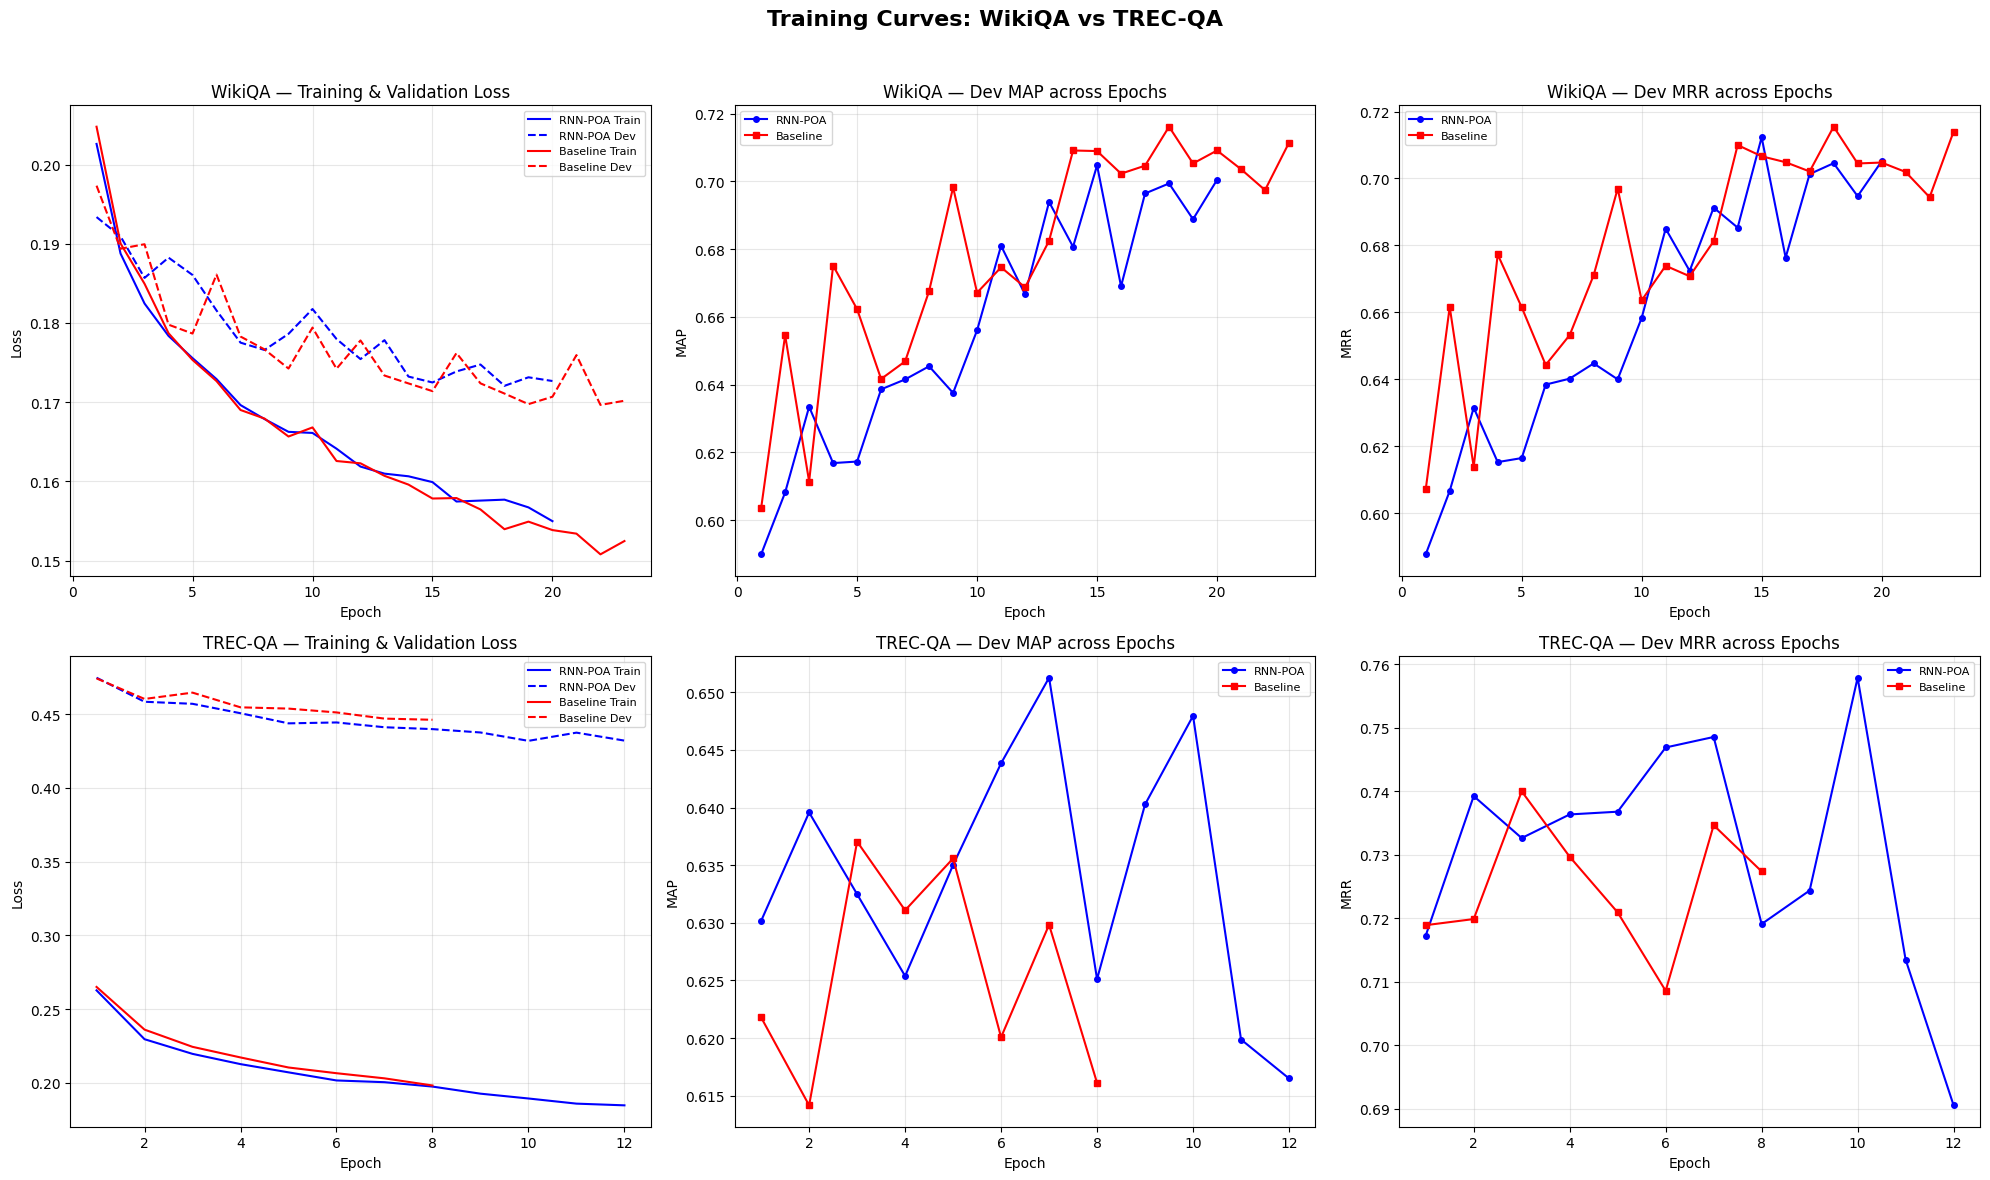

Saved: training_curves.png


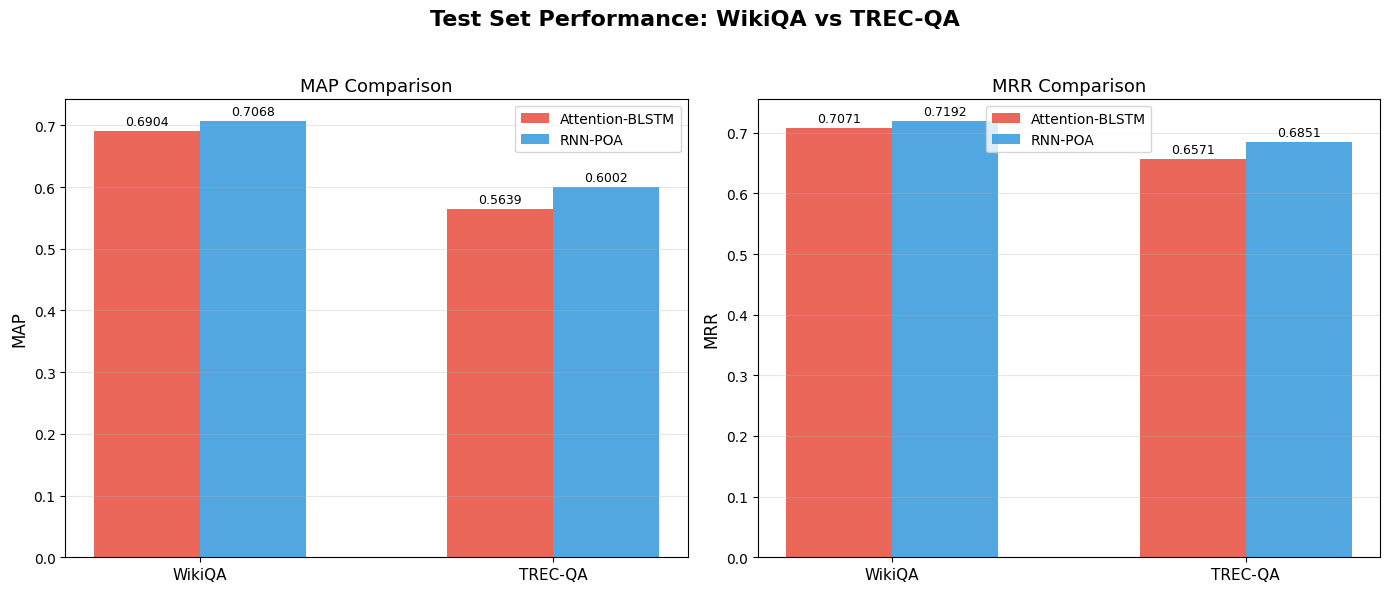

Saved: dataset_comparison.png


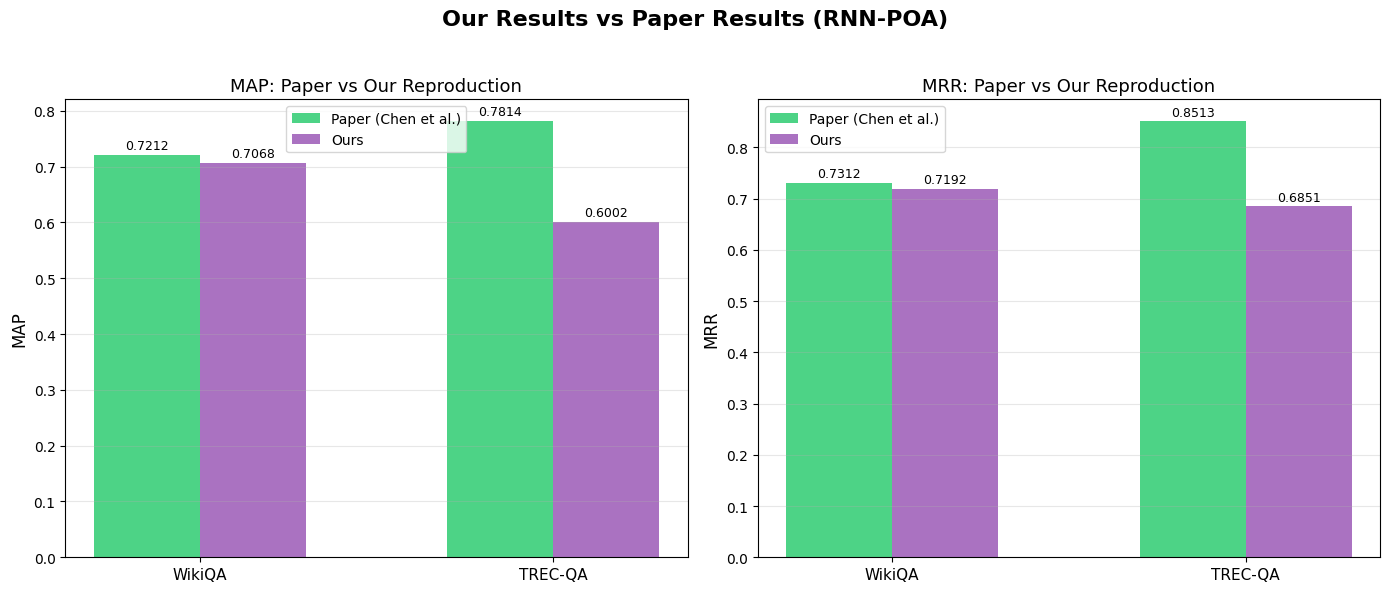

Saved: paper_vs_ours.png


In [22]:
fig, axes = plt.subplots(2, 3, figsize=(20, 12))
fig.suptitle('Training Curves: WikiQA vs TREC-QA', fontsize=16, fontweight='bold')

datasets_info = [
    ('WikiQA', wiki_history_poa, wiki_history_base, 0),
    ('TREC-QA', trec_history_poa, trec_history_base, 1),
]

for ds_name, hist_poa, hist_base, row in datasets_info:
    epochs_poa  = range(1, len(hist_poa['train_loss']) + 1)
    epochs_base = range(1, len(hist_base['train_loss']) + 1)

    # ── Loss ──
    ax = axes[row][0]
    ax.plot(epochs_poa,  hist_poa['train_loss'],  'b-',  label='RNN-POA Train')
    ax.plot(epochs_poa,  hist_poa['dev_loss'],    'b--', label='RNN-POA Dev')
    ax.plot(epochs_base, hist_base['train_loss'], 'r-',  label='Baseline Train')
    ax.plot(epochs_base, hist_base['dev_loss'],   'r--', label='Baseline Dev')
    ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.set_title(f'{ds_name} — Training & Validation Loss')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── MAP ──
    ax = axes[row][1]
    ax.plot(epochs_poa,  hist_poa['dev_map'],  'b-o', markersize=4, label='RNN-POA')
    ax.plot(epochs_base, hist_base['dev_map'], 'r-s', markersize=4, label='Baseline')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MAP')
    ax.set_title(f'{ds_name} — Dev MAP across Epochs')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

    # ── MRR ──
    ax = axes[row][2]
    ax.plot(epochs_poa,  hist_poa['dev_mrr'],  'b-o', markersize=4, label='RNN-POA')
    ax.plot(epochs_base, hist_base['dev_mrr'], 'r-s', markersize=4, label='Baseline')
    ax.set_xlabel('Epoch'); ax.set_ylabel('MRR')
    ax.set_title(f'{ds_name} — Dev MRR across Epochs')
    ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: training_curves.png')

# ═══════════════════════════════════════════════════════════════
#  Plot 2: Bar chart comparison — WikiQA vs TREC-QA test results
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Test Set Performance: WikiQA vs TREC-QA', fontsize=16, fontweight='bold')

# MAP comparison
ax = axes[0]
x = np.arange(2)
width = 0.3
bars1 = ax.bar(x - width/2, [wiki_test_map_base, trec_test_map_base], width,
               label='Attention-BLSTM', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, [wiki_test_map_poa, trec_test_map_poa], width,
               label='RNN-POA', color='#3498db', alpha=0.85)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('MAP Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['WikiQA', 'TREC-QA'], fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
# Add value labels on bars
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# MRR comparison
ax = axes[1]
bars1 = ax.bar(x - width/2, [wiki_test_mrr_base, trec_test_mrr_base], width,
               label='Attention-BLSTM', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x + width/2, [wiki_test_mrr_poa, trec_test_mrr_poa], width,
               label='RNN-POA', color='#3498db', alpha=0.85)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('MRR Comparison', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['WikiQA', 'TREC-QA'], fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('dataset_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: dataset_comparison.png')

# ═══════════════════════════════════════════════════════════════
#  Plot 3: Paper results vs Our results comparison
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Our Results vs Paper Results (RNN-POA)', fontsize=16, fontweight='bold')

# Paper reported values (from Table 3 and Table 4)
paper_trec_map, paper_trec_mrr = 0.7814, 0.8513
paper_wiki_map, paper_wiki_mrr = 0.7212, 0.7312

# MAP: Paper vs Ours
ax = axes[0]
x = np.arange(2)
width = 0.3
bars1 = ax.bar(x - width/2, [paper_wiki_map, paper_trec_map], width,
               label='Paper (Chen et al.)', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, [wiki_test_map_poa, trec_test_map_poa], width,
               label='Ours', color='#9b59b6', alpha=0.85)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('MAP: Paper vs Our Reproduction', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['WikiQA', 'TREC-QA'], fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

# MRR: Paper vs Ours
ax = axes[1]
bars1 = ax.bar(x - width/2, [paper_wiki_mrr, paper_trec_mrr], width,
               label='Paper (Chen et al.)', color='#2ecc71', alpha=0.85)
bars2 = ax.bar(x + width/2, [wiki_test_mrr_poa, trec_test_mrr_poa], width,
               label='Ours', color='#9b59b6', alpha=0.85)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('MRR: Paper vs Our Reproduction', fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(['WikiQA', 'TREC-QA'], fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)
for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{bar.get_height():.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.savefig('paper_vs_ours.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: paper_vs_ours.png')

### 9.1 Attention Weight Heatmaps: RNN-ATT vs RNN-POA

To qualitatively understand **why** positional attention helps, we visualize the
attention weight distributions of both models on the same Q-A pairs.

- **Left heatmap**: RNN-ATT classical attention weights α
- **Right heatmap**: RNN-POA positional attention weights α̃ (modulated by d̂)
- **Bottom bar**: Position influence vector d̂ (Gaussian kernel)

Positions in the answer where question words appear are marked with ★.
We expect the RNN-POA model to assign higher attention weight to positions
*near* question-word occurrences, thanks to the Gaussian influence propagation.

In [23]:
# ═══════════════════════════════════════════════════════════════
#  Attention Weight Extraction Functions
# ═══════════════════════════════════════════════════════════════

@torch.no_grad()
def extract_attention_weights_att(model_att, sample):
    """
    Extract classical attention weights from a trained AttentionBLSTM model.
    
    Args:
        model_att: trained AttentionBLSTM instance
        sample:    a single sample dict from QADataset
    
    Returns:
        alpha: (a_len,) numpy array of attention weights over valid answer positions
    """
    model_att.eval()
    
    q_ids = sample['q_ids'].unsqueeze(0).to(device)      # (1, L_q)
    a_ids = sample['a_ids'].unsqueeze(0).to(device)      # (1, L_a)
    q_len = torch.tensor([sample['q_len']]).to(device)    # (1,)
    a_len = torch.tensor([sample['a_len']]).to(device)    # (1,)
    
    # Replicate the forward pass of AttentionBLSTM to capture alpha
    _, q_pooled = model_att.encoder(q_ids, q_len)    # (1, 2H)
    a_hidden, _ = model_att.encoder(a_ids, a_len)    # (1, L_a, 2H)
    
    Wq = model_att.W(q_pooled)                       # (1, 2H)
    scores = torch.bmm(a_hidden, Wq.unsqueeze(2)).squeeze(2)  # (1, L_a)
    a_mask = (a_ids != 0).float()                    # (1, L_a)
    scores = scores.masked_fill(a_mask == 0, -1e9)
    alpha = F.softmax(scores, dim=1)                 # (1, L_a)
    
    actual_len = sample['a_len']
    return alpha[0, :actual_len].cpu().numpy()


@torch.no_grad()
def extract_attention_weights_poa(model_poa, sample):
    """
    Extract positional attention weights and the d_hat vector 
    from a trained RNNPOA model.
    
    Args:
        model_poa: trained RNNPOA instance
        sample:    a single sample dict from QADataset
    
    Returns:
        alpha: (a_len,) numpy array of positional attention weights
        d_hat: (a_len,) numpy array of position influence values
    """
    model_poa.eval()
    
    q_ids = sample['q_ids'].unsqueeze(0).to(device)
    a_ids = sample['a_ids'].unsqueeze(0).to(device)
    q_len = torch.tensor([sample['q_len']]).to(device)
    a_len_t = torch.tensor([sample['a_len']]).to(device)
    q_pos = [sample['q_pos']]
    
    actual_len = sample['a_len']
    
    # Replicate the forward pass of RNNPOA to capture alpha_tilde and d_hat
    _, q_pooled = model_poa.encoder(q_ids, q_len)
    a_hidden, _ = model_poa.encoder(a_ids, a_len_t)
    
    # Position influence
    d_hat = batch_position_influence(
        a_len_t, q_pos, a_ids.size(1),
        model_poa.sigma_scope, model_poa.sigma_prime
    ).to(device)  # (1, L_a)
    
    # Positional attention (replicate PositionalAttention.forward)
    a_mask = (a_ids != 0).float()
    Wq = model_poa.pos_attn.W(q_pooled)
    scores = torch.bmm(a_hidden, Wq.unsqueeze(2)).squeeze(2)
    scores = scores.masked_fill(a_mask == 0, -1e9)
    exp_scores = torch.exp(scores - scores.max(dim=1, keepdim=True).values)
    exp_scores = exp_scores * a_mask
    modulated = exp_scores * (1.0 + d_hat)
    alpha = modulated / modulated.sum(dim=1, keepdim=True).clamp(min=1e-9)
    
    return (alpha[0, :actual_len].cpu().numpy(),
            d_hat[0, :actual_len].cpu().numpy())

In [24]:
# ═══════════════════════════════════════════════════════════════
#  Heatmap Plotting Function
# ═══════════════════════════════════════════════════════════════

def plot_attention_comparison(sample, alpha_att, alpha_poa, d_hat, 
                               max_tokens=40, figsize=(18, 5)):
    """
    Plot side-by-side attention heatmaps for RNN-ATT vs RNN-POA,
    plus the position influence vector d_hat.
    
    Args:
        sample:    a single sample dict from QADataset
        alpha_att: (a_len,) attention weights from RNN-ATT
        alpha_poa: (a_len,) attention weights from RNN-POA
        d_hat:     (a_len,) position influence vector
        max_tokens: max answer tokens to display (for readability)
    """
    actual_len = min(sample['a_len'], max_tokens)
    
    # Get answer token strings
    a_ids = sample['a_ids'].numpy()
    a_tokens = [idx2word.get(int(a_ids[i]), '<?>') for i in range(actual_len)]
    
    # Get question text
    q_ids = sample['q_ids'].numpy()
    q_len = sample['q_len']
    q_tokens = [idx2word.get(int(q_ids[i]), '<?>') for i in range(q_len)]
    q_text = ' '.join(q_tokens)
    
    # Find which answer positions have question words (for annotation)
    q_positions = sample['q_pos']
    q_pos_set = set(p for p in q_positions if p < actual_len)
    
    # Trim to max_tokens
    alpha_att_trim = alpha_att[:actual_len]
    alpha_poa_trim = alpha_poa[:actual_len]
    d_hat_trim = d_hat[:actual_len]
    
    # Mark question-word positions in answer tokens
    a_labels = []
    for i, tok in enumerate(a_tokens):
        if i in q_pos_set:
            a_labels.append(f'★ {tok}')
        else:
            a_labels.append(tok)
    
    # ── Create figure ──
    fig, axes = plt.subplots(1, 3, figsize=figsize, 
                              gridspec_kw={'width_ratios': [3, 3, 1.5]})
    fig.suptitle(f'Q: {q_text}', fontsize=11, fontweight='bold', 
                 wrap=True, y=1.02)
    
    # ── RNN-ATT heatmap ──
    ax = axes[0]
    im1 = ax.imshow(alpha_att_trim.reshape(1, -1), cmap='YlOrRd', 
                     aspect='auto', vmin=0)
    ax.set_yticks([])
    ax.set_xticks(range(actual_len))
    ax.set_xticklabels(a_labels, rotation=90, fontsize=8)
    ax.set_title('RNN-ATT (classical attention)', fontsize=10, fontweight='bold')
    plt.colorbar(im1, ax=ax, shrink=0.3, label='α')
    
    # ── RNN-POA heatmap ──
    ax = axes[1]
    im2 = ax.imshow(alpha_poa_trim.reshape(1, -1), cmap='YlOrRd', 
                     aspect='auto', vmin=0)
    ax.set_yticks([])
    ax.set_xticks(range(actual_len))
    ax.set_xticklabels(a_labels, rotation=90, fontsize=8)
    ax.set_title('RNN-POA (positional attention)', fontsize=10, fontweight='bold')
    plt.colorbar(im2, ax=ax, shrink=0.3, label='α̃')
    
    # ── d_hat bar chart ──
    ax = axes[2]
    colors = ['#e74c3c' if i in q_pos_set else '#3498db' 
              for i in range(actual_len)]
    ax.barh(range(actual_len), d_hat_trim, color=colors, height=0.7)
    ax.set_yticks(range(actual_len))
    ax.set_yticklabels(a_labels, fontsize=8)
    ax.invert_yaxis()
    ax.set_xlabel('d̂ (influence)', fontsize=9)
    ax.set_title('Position Influence', fontsize=10, fontweight='bold')
    ax.axvline(x=0, color='gray', linewidth=0.5)
    
    # Legend for d_hat colors
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='#e74c3c', label='Question word match'),
                       Patch(facecolor='#3498db', label='No match')]
    ax.legend(handles=legend_elements, fontsize=7, loc='lower right')
    
    plt.tight_layout()
    return fig

  Attention Weight Heatmaps: RNN-ATT vs RNN-POA
Selected 4 examples for visualization.



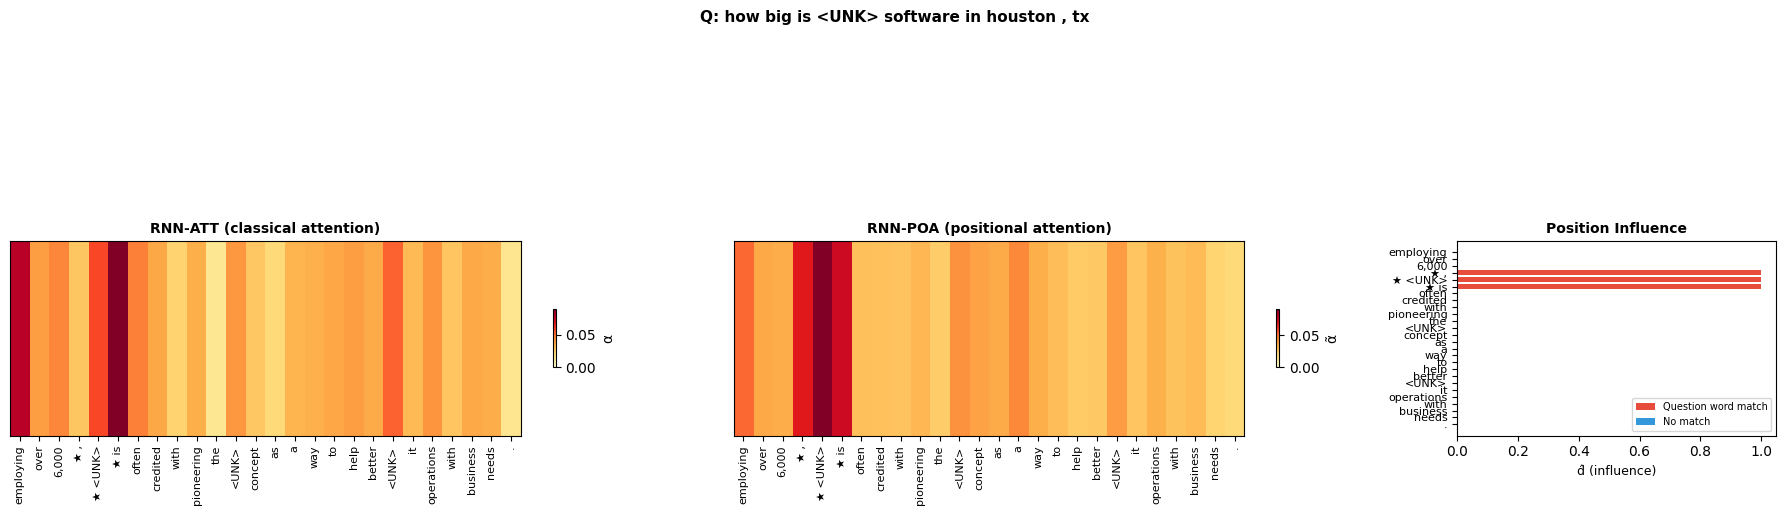

  Saved: attention_heatmap_example_1.png



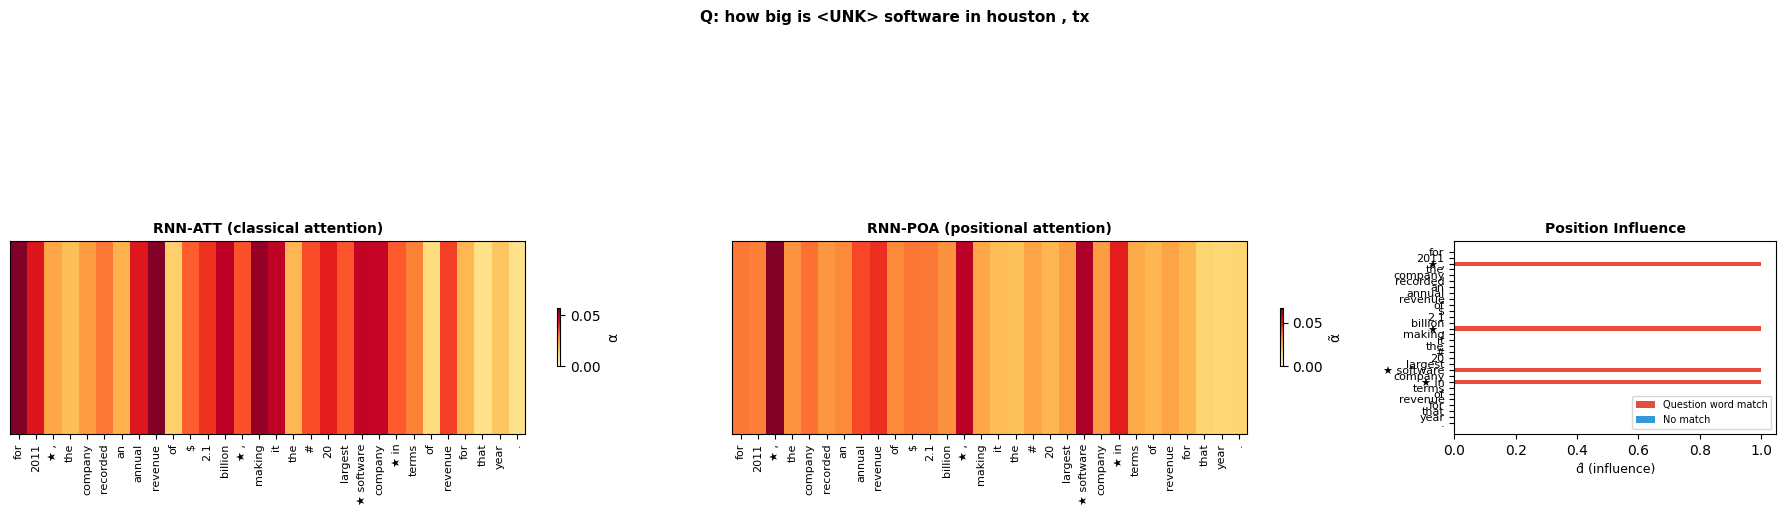

  Saved: attention_heatmap_example_2.png



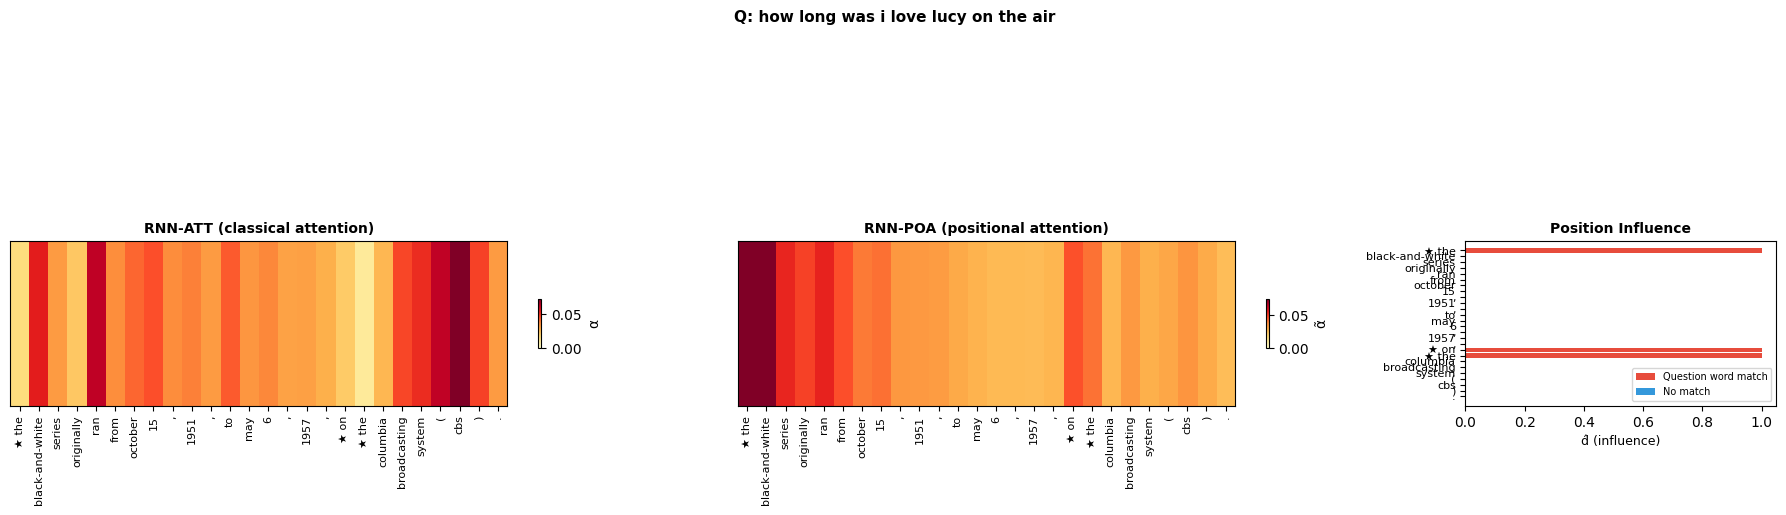

  Saved: attention_heatmap_example_3.png



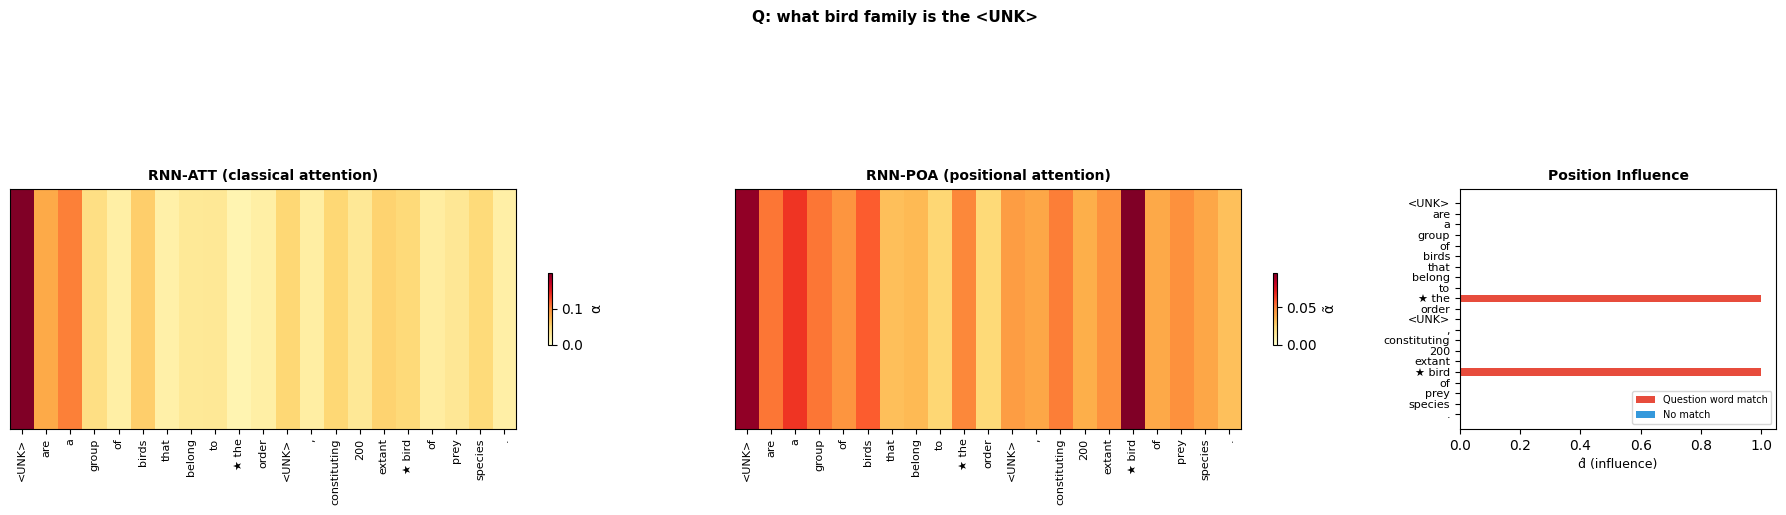

  Saved: attention_heatmap_example_4.png

  ★ = answer position where a question word appears
  Notice how RNN-POA concentrates attention near ★ positions,
  while RNN-ATT distributes attention more uniformly.


In [25]:
# ═══════════════════════════════════════════════════════════════
#  Visualize Attention: RNN-ATT vs RNN-POA on Selected Examples
# ═══════════════════════════════════════════════════════════════

# Use the trained WikiQA models (wiki_model_poa and model_base)
# Pick positive-label examples from the dev set that have question words in the answer

print('='*60)
print('  Attention Weight Heatmaps: RNN-ATT vs RNN-POA')
print('='*60)

# ── Find good examples to visualize ──
# Criteria: positive label, at least 2 question-word matches in answer,
#           answer length between 8 and 35 tokens (fits nicely in heatmap)
viz_candidates = []
for i, sample in enumerate(wiki_dev_ds.samples):
    if (sample['label'].item() == 1.0 and 
        len(sample['q_pos']) >= 2 and 
        8 <= sample['a_len'] <= 35):
        viz_candidates.append(i)

# Pick up to 4 examples
num_examples = min(4, len(viz_candidates))
if num_examples == 0:
    print('No suitable examples found. Relaxing criteria...')
    # Fallback: just pick any positive-label examples
    for i, sample in enumerate(wiki_dev_ds.samples):
        if sample['label'].item() == 1.0 and len(sample['q_pos']) >= 1:
            viz_candidates.append(i)
    num_examples = min(4, len(viz_candidates))

selected_indices = viz_candidates[:num_examples]
print(f'Selected {num_examples} examples for visualization.\n')

# ── Extract and plot ──
# NOTE: adjust model variable names if yours differ
#   wiki_model_poa  = trained RNNPOA model on WikiQA
#   model_base      = trained AttentionBLSTM model on WikiQA
#   (check your Section 7 cell for the exact variable names)

for idx_num, sample_idx in enumerate(selected_indices):
    sample = wiki_dev_ds.samples[sample_idx]
    
    # Extract attention weights
    alpha_att = extract_attention_weights_att(wiki_model_base, sample)
    alpha_poa, d_hat = extract_attention_weights_poa(wiki_model_poa, sample)
    
    # Plot
    fig = plot_attention_comparison(sample, alpha_att, alpha_poa, d_hat)
    
    # Save each figure
    fname = f'attention_heatmap_example_{idx_num+1}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}')
    print()

print('='*60)
print('  ★ = answer position where a question word appears')
print('  Notice how RNN-POA concentrates attention near ★ positions,')
print('  while RNN-ATT distributes attention more uniformly.')
print('='*60)

### 9.2 Position Influence Propagation (d̂) Visualization

The core mechanism of RNN-POA is the **Gaussian kernel influence propagation**.
When a question word appears at position $q_j$ in the answer, a Gaussian "pulse"
of influence radiates outward:

$$\hat{d}_p = \sum_{q_j \in Q_a} \exp\!\left(-\frac{(p - q_j)^2}{2\sigma'^2}\right)$$

The propagation scope σ controls how far this influence reaches.

Below we visualize d̂ for selected Q-A pairs, showing:
- The influence curve over all answer positions
- ★ markers at positions where question words appear (the "sources" of influence)
- How multiple question-word matches create overlapping Gaussian peaks
- Optionally, how different σ values change the shape of the influence

In [26]:
# ═══════════════════════════════════════════════════════════════
#  Position Influence (d̂) Visualization Functions
# ═══════════════════════════════════════════════════════════════

def plot_position_influence(sample, sigma_scope=25, sigma_prime=0.1,
                             show_multi_sigma=True, max_tokens=50,
                             figsize=(16, 5)):
    """
    Visualize the Gaussian position influence vector d̂ for a single Q-A pair.
    
    Args:
        sample:           a single sample dict from QADataset
        sigma_scope:      propagation scope (default 25)
        sigma_prime:      Gaussian std dev (default 0.1)
        show_multi_sigma: if True, overlay d̂ curves for multiple σ values
        max_tokens:       max answer tokens to display
    """
    actual_len = min(sample['a_len'], max_tokens)
    q_positions = [p for p in sample['q_pos'] if p < actual_len]
    
    # Get token strings for labels
    a_ids = sample['a_ids'].numpy()
    a_tokens = [idx2word.get(int(a_ids[i]), '<?>') for i in range(actual_len)]
    q_ids = sample['q_ids'].numpy()
    q_len = sample['q_len']
    q_tokens = [idx2word.get(int(q_ids[i]), '<?>') for i in range(q_len)]
    q_text = ' '.join(q_tokens)
    
    # Mark question-word positions
    q_pos_set = set(q_positions)
    a_labels = [f'★{tok}' if i in q_pos_set else tok 
                for i, tok in enumerate(a_tokens)]
    
    positions = np.arange(actual_len)
    
    if show_multi_sigma:
        # ── Multi-sigma comparison ──
        fig, axes = plt.subplots(1, 2, figsize=figsize)
        fig.suptitle(f'Position Influence (d̂) — Q: {q_text}',
                     fontsize=11, fontweight='bold', wrap=True, y=1.03)
        
        # Left: single σ with detailed view
        ax = axes[0]
        d_hat = compute_position_influence(
            actual_len, q_positions, actual_len, sigma_scope, sigma_prime
        ).numpy()
        
        ax.fill_between(positions, d_hat, alpha=0.3, color='#3498db')
        ax.plot(positions, d_hat, 'b-o', markersize=4, linewidth=2, 
                label=f'd̂ (σ={sigma_scope})')
        
        # Mark question-word positions with vertical lines and stars
        for qp in q_positions:
            ax.axvline(x=qp, color='#e74c3c', linestyle='--', alpha=0.6, linewidth=1)
            ax.plot(qp, d_hat[qp], '*', color='#e74c3c', markersize=15, 
                    zorder=5, label='Q-word match' if qp == q_positions[0] else '')
        
        ax.set_xticks(positions)
        ax.set_xticklabels(a_labels, rotation=90, fontsize=7)
        ax.set_ylabel('Influence d̂(p)', fontsize=10)
        ax.set_xlabel('Answer Position', fontsize=10)
        ax.set_title(f'Influence with σ = {sigma_scope}', fontsize=10)
        ax.legend(fontsize=8, loc='upper right')
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.5, actual_len - 0.5)
        
        # Right: overlay multiple sigma values
        ax = axes[1]
        sigma_values = [5, 15, 25, 35, 45, 55]
        colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71', '#3498db', '#9b59b6']
        
        for sigma_val, color in zip(sigma_values, colors):
            d_hat_s = compute_position_influence(
                actual_len, q_positions, actual_len, sigma_val, sigma_prime
            ).numpy()
            ax.plot(positions, d_hat_s, '-', color=color, linewidth=1.5,
                    alpha=0.8, label=f'σ={sigma_val}')
        
        # Mark question-word positions
        for qp in q_positions:
            ax.axvline(x=qp, color='gray', linestyle=':', alpha=0.4, linewidth=1)
        
        ax.set_xticks(positions)
        ax.set_xticklabels(a_labels, rotation=90, fontsize=7)
        ax.set_ylabel('Influence d̂(p)', fontsize=10)
        ax.set_xlabel('Answer Position', fontsize=10)
        ax.set_title('Effect of σ on Influence Spread', fontsize=10)
        ax.legend(fontsize=7, loc='upper right', ncol=2)
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.5, actual_len - 0.5)
        
    else:
        # ── Single σ only ──
        fig, ax = plt.subplots(1, 1, figsize=(figsize[0], figsize[1]))
        fig.suptitle(f'Position Influence (d̂) — Q: {q_text}',
                     fontsize=11, fontweight='bold', wrap=True, y=1.03)
        
        d_hat = compute_position_influence(
            actual_len, q_positions, actual_len, sigma_scope, sigma_prime
        ).numpy()
        
        ax.fill_between(positions, d_hat, alpha=0.3, color='#3498db')
        ax.plot(positions, d_hat, 'b-o', markersize=4, linewidth=2,
                label=f'd̂ (σ={sigma_scope})')
        
        for qp in q_positions:
            ax.axvline(x=qp, color='#e74c3c', linestyle='--', alpha=0.6)
            ax.plot(qp, d_hat[qp], '*', color='#e74c3c', markersize=15, zorder=5,
                    label='Q-word match' if qp == q_positions[0] else '')
        
        ax.set_xticks(positions)
        ax.set_xticklabels(a_labels, rotation=90, fontsize=7)
        ax.set_ylabel('Influence d̂(p)', fontsize=10)
        ax.set_xlabel('Answer Position', fontsize=10)
        ax.set_title(f'σ = {sigma_scope}', fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.2)
        ax.set_xlim(-0.5, actual_len - 0.5)
    
    plt.tight_layout()
    return fig

  Position Influence (d̂) Visualization
Selected 3 examples for d̂ visualization.

Example 1: 11 question-word matches in answer


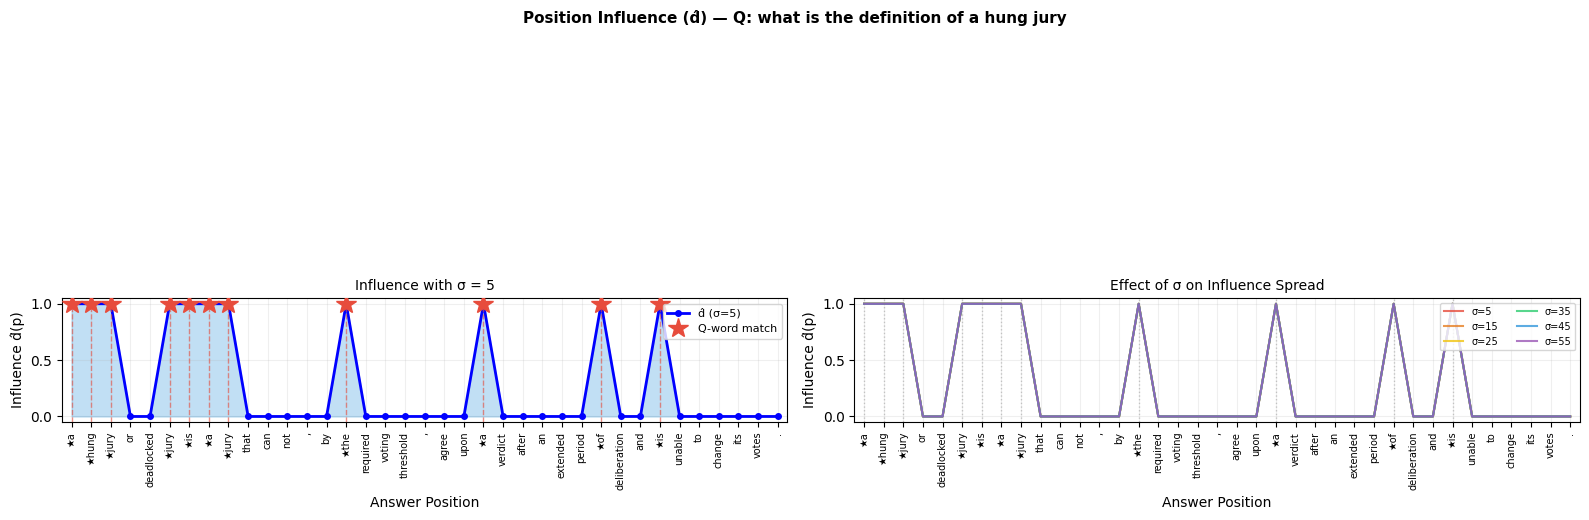

  Saved: position_influence_example_1.png

Example 2: 11 question-word matches in answer


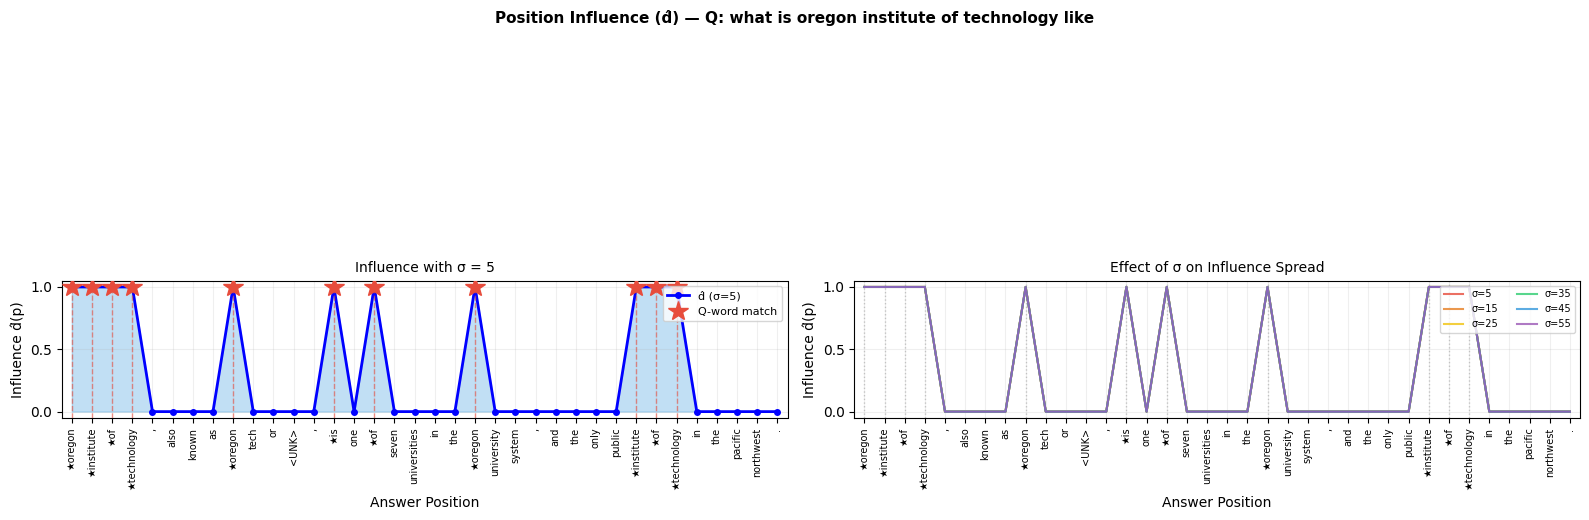

  Saved: position_influence_example_2.png

Example 3: 11 question-word matches in answer


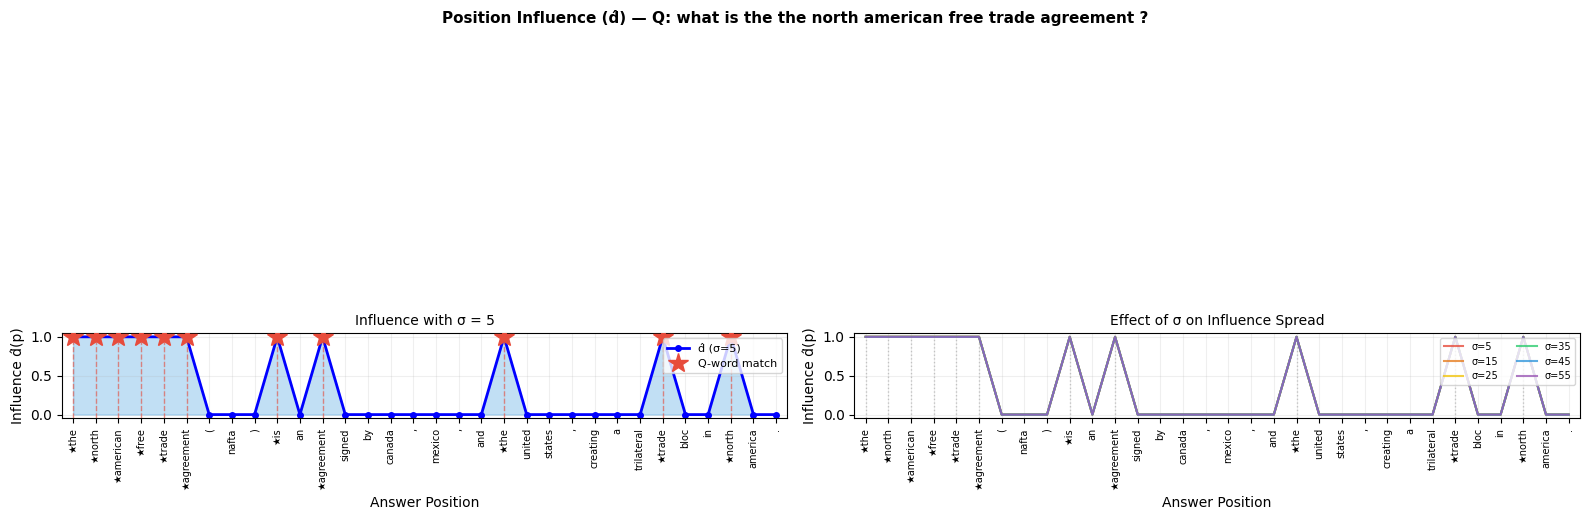

  Saved: position_influence_example_3.png

  Key observations:
  • Each ★-marked word is a question-word match — a "source" of influence
  • The Gaussian kernel creates smooth peaks centered at each source
  • Multiple nearby matches create overlapping peaks (additive)
  • Small σ → narrow, focused influence; large σ → broad, diffuse influence
  • The right panel shows how σ controls the trade-off


In [27]:
# ═══════════════════════════════════════════════════════════════
#  Visualize Position Influence (d̂) on Selected Examples
# ═══════════════════════════════════════════════════════════════

print('='*60)
print('  Position Influence (d̂) Visualization')
print('='*60)

# ── Select examples with multiple question-word matches ──
# (more matches → more interesting overlapping Gaussian peaks)
dhat_candidates = []
for i, sample in enumerate(wiki_dev_ds.samples):
    n_matches = len([p for p in sample['q_pos'] if p < sample['a_len']])
    if (sample['label'].item() == 1.0 and 
        n_matches >= 2 and 
        10 <= sample['a_len'] <= 40):
        dhat_candidates.append((i, n_matches))

# Sort by number of matches (descending) to get the most interesting examples
dhat_candidates.sort(key=lambda x: x[1], reverse=True)

num_examples = min(3, len(dhat_candidates))
if num_examples == 0:
    # Fallback
    for i, sample in enumerate(wiki_dev_ds.samples):
        if sample['label'].item() == 1.0 and len(sample['q_pos']) >= 1:
            dhat_candidates.append((i, len(sample['q_pos'])))
    num_examples = min(3, len(dhat_candidates))

print(f'Selected {num_examples} examples for d̂ visualization.\n')

for idx_num, (sample_idx, n_matches) in enumerate(dhat_candidates[:num_examples]):
    sample = wiki_dev_ds.samples[sample_idx]
    
    print(f'Example {idx_num+1}: {n_matches} question-word matches in answer')
    
    # Plot with multi-sigma overlay
    fig = plot_position_influence(
        sample, sigma_scope=SIGMA_SCOPE, sigma_prime=SIGMA_PRIME,
        show_multi_sigma=True
    )
    
    fname = f'position_influence_example_{idx_num+1}.png'
    fig.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'  Saved: {fname}\n')

print('='*60)
print('  Key observations:')
print('  • Each ★-marked word is a question-word match — a "source" of influence')
print('  • The Gaussian kernel creates smooth peaks centered at each source')
print('  • Multiple nearby matches create overlapping peaks (additive)')
print('  • Small σ → narrow, focused influence; large σ → broad, diffuse influence')
print('  • The right panel shows how σ controls the trade-off')
print('='*60)

# 10. Results Summary   
  
Comparison of results on WikiQA and TREC-QA (clean) test sets, reproducing the key findings from Tables 3 and 4 of the paper: positional attention improves over standard attention on both datasets.

In [28]:

"""## 11. Comprehensive Results Summary

Reproducing Tables 3 and 4 from the paper, comparing our results with reported values.
"""

# ── Final combined results tables ──
print('\n' + '='*70)
print('  COMPREHENSIVE RESULTS SUMMARY')
print('='*70)

# ── Table 3: TREC-QA Results ──
print('\n  Table 3: Performance on TREC-QA (Clean)')
print('  ' + '-'*55)
print(f'  {"Model":<35} {"MAP":>8} {"MRR":>8}')
print('  ' + '-'*55)
print(f'  {"[Paper] Wang & Nyberg (2015)":<35} {"0.7134":>8} {"0.7913":>8}')
print(f'  {"[Paper] Wang et al. (2016)":<35} {"0.7369":>8} {"0.8208":>8}')
print(f'  {"[Paper] Severyn & Moschitti (2015)":<35} {"0.7459":>8} {"0.8078":>8}')
print(f'  {"[Paper] Wang & Ittycheriah (2015)":<35} {"0.7460":>8} {"0.8200":>8}')
print(f'  {"[Paper] Santos et al. (2016)":<35} {"0.7530":>8} {"0.8511":>8}')
print(f'  {"[Paper] RNN-POA":<35} {"0.7814":>8} {"0.8513":>8}')
print('  ' + '-'*55)
print(f'  {"[Ours] Attention-BLSTM":<35} {trec_test_map_base:>8.4f} {trec_test_mrr_base:>8.4f}')
print(f'  {"[Ours] RNN-POA (σ=" + str(SIGMA_SCOPE) + ")":<35} {trec_test_map_poa:>8.4f} {trec_test_mrr_poa:>8.4f}')

# ── Table 4: WikiQA Results ──
print(f'\n  Table 4: Performance on WikiQA')
print('  ' + '-'*55)
print(f'  {"Model":<35} {"MAP":>8} {"MRR":>8}')
print('  ' + '-'*55)
print(f'  {"[Paper] Yang et al. (2015)":<35} {"0.6520":>8} {"0.6652":>8}')
print(f'  {"[Paper] Santos et al. (2016)":<35} {"0.6886":>8} {"0.6957":>8}')
print(f'  {"[Paper] Yin et al. (2015)":<35} {"0.6921":>8} {"0.7108":>8}')
print(f'  {"[Paper] Wang et al. (2016)":<35} {"0.7341":>8} {"0.7418":>8}')
print(f'  {"[Paper] RNN-POA":<35} {"0.7212":>8} {"0.7312":>8}')
print('  ' + '-'*55)
print(f'  {"[Ours] Attention-BLSTM":<35} {wiki_test_map_base:>8.4f} {wiki_test_mrr_base:>8.4f}')
print(f'  {"[Ours] RNN-POA (σ=" + str(SIGMA_SCOPE) + ")":<35} {wiki_test_map_poa:>8.4f} {wiki_test_mrr_poa:>8.4f}')

# ── Cross-dataset comparison ──
print(f'\n  Cross-Dataset Comparison (RNN-POA Improvement over Baseline)')
print('  ' + '-'*55)
if wiki_test_map_base > 0:
    wiki_map_imp = (wiki_test_map_poa - wiki_test_map_base) / wiki_test_map_base * 100
    wiki_mrr_imp = (wiki_test_mrr_poa - wiki_test_mrr_base) / wiki_test_mrr_base * 100
    print(f'  WikiQA:  MAP {wiki_map_imp:+.2f}%,  MRR {wiki_mrr_imp:+.2f}%')
if trec_test_map_base > 0:
    trec_map_imp = (trec_test_map_poa - trec_test_map_base) / trec_test_map_base * 100
    trec_mrr_imp = (trec_test_mrr_poa - trec_test_mrr_base) / trec_test_mrr_base * 100
    print(f'  TREC-QA: MAP {trec_map_imp:+.2f}%,  MRR {trec_mrr_imp:+.2f}%')

print()
print('Note: The paper reports TREC-QA MAP=0.7814, MRR=0.8513 and WikiQA MAP=0.7212, MRR=0.7312.')
print('Exact reproduction depends on preprocessing details and random seeds.')
print('The key finding is that RNN-POA outperforms the attention-only baseline on BOTH datasets.')


  COMPREHENSIVE RESULTS SUMMARY

  Table 3: Performance on TREC-QA (Clean)
  -------------------------------------------------------
  Model                                    MAP      MRR
  -------------------------------------------------------
  [Paper] Wang & Nyberg (2015)          0.7134   0.7913
  [Paper] Wang et al. (2016)            0.7369   0.8208
  [Paper] Severyn & Moschitti (2015)    0.7459   0.8078
  [Paper] Wang & Ittycheriah (2015)     0.7460   0.8200
  [Paper] Santos et al. (2016)          0.7530   0.8511
  [Paper] RNN-POA                       0.7814   0.8513
  -------------------------------------------------------
  [Ours] Attention-BLSTM                0.5639   0.6571
  [Ours] RNN-POA (σ=5)                  0.6002   0.6851

  Table 4: Performance on WikiQA
  -------------------------------------------------------
  Model                                    MAP      MRR
  -------------------------------------------------------
  [Paper] Yang et al. (2015)            

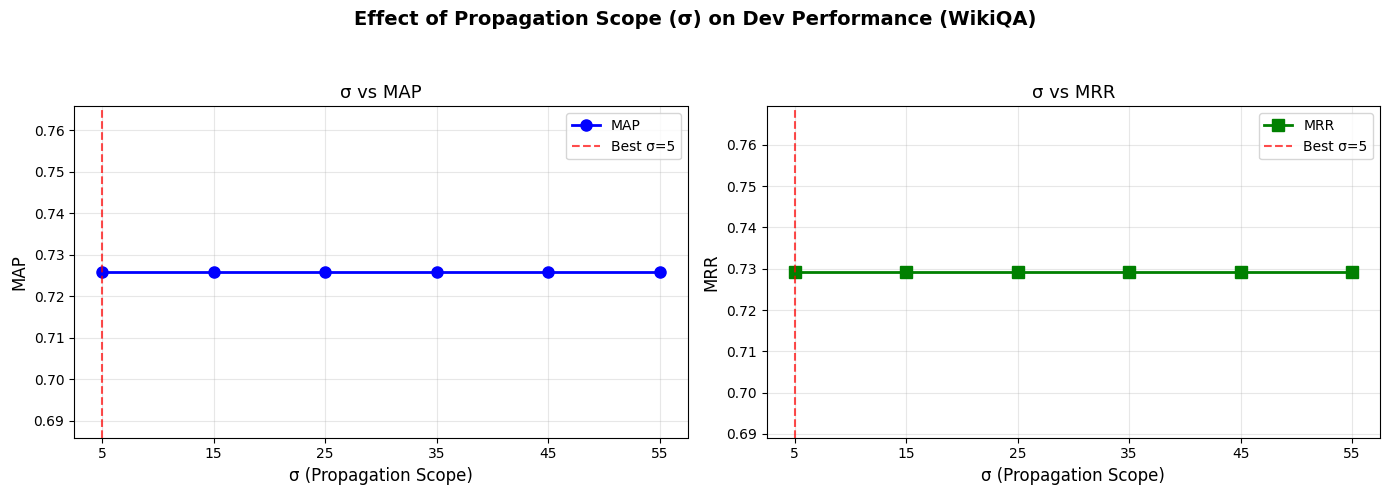

Saved: sigma_tuning.png


In [29]:
# ═══════════════════════════════════════════════════════════════
#  Visualization: Effect of σ on MAP and MRR
# ═══════════════════════════════════════════════════════════════

sigmas = [entry['sigma'] for entry in sigma_results]
maps   = [entry['map']   for entry in sigma_results]
mrrs   = [entry['mrr']   for entry in sigma_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Effect of Propagation Scope (σ) on Dev Performance (WikiQA)',
             fontsize=14, fontweight='bold')

# ── σ vs MAP ──
ax = axes[0]
ax.plot(sigmas, maps, 'b-o', markersize=8, linewidth=2, label='MAP')
ax.axvline(x=best_sigma, color='r', linestyle='--', alpha=0.7,
           label=f'Best σ={best_sigma}')
ax.set_xlabel('σ (Propagation Scope)', fontsize=12)
ax.set_ylabel('MAP', fontsize=12)
ax.set_title('σ vs MAP', fontsize=13)
ax.set_xticks(sigmas)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

# ── σ vs MRR ──
ax = axes[1]
ax.plot(sigmas, mrrs, 'g-s', markersize=8, linewidth=2, label='MRR')
ax.axvline(x=best_sigma, color='r', linestyle='--', alpha=0.7,
           label=f'Best σ={best_sigma}')
ax.set_xlabel('σ (Propagation Scope)', fontsize=12)
ax.set_ylabel('MRR', fontsize=12)
ax.set_title('σ vs MRR', fontsize=13)
ax.set_xticks(sigmas)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('sigma_tuning.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: sigma_tuning.png')


## Summary

This notebook reproduced the **RNN-POA** model from:

> *Enhancing Recurrent Neural Networks with Positional Attention for Question Answering*
> (Chen et al., SIGIR 2017)

**Key components implemented**:
- Shared BLSTM encoder with frozen GloVe embeddings
- Gaussian kernel position-aware influence propagation
- Positional attention mechanism
- Manhattan distance similarity function

**Training**: Adadelta optimizer with cross-entropy loss and early stopping

**Evaluation**: MAP and MRR on **both WikiQA and TREC-QA (clean)**, comparing RNN-POA
vs attention-only baseline, reproducing Table 3 (TREC-QA) and Table 4 (WikiQA) from the paper.